# Module 4 Lab: Build and Evaluate a Titanic Classifier

**Practical Machine Learning Foundations**

**Purpose:** split the Titanic data honestly, train a logistic regression and then the same problem with a dozen other algorithms, cross-validate them properly, and evaluate everything with the full metrics toolkit including ROC and PR curves.

**Date:** 2026-08-24 | **Author:** Nick Garner

In the preceding lessons the data got cleaned, encoded, and scaled. Now it finally meets a model. Three ideas run through everything below:

1. **A number measured on training data is not a result.** Every honest estimate comes from data the model has never seen.
2. **Accuracy is the metric most likely to lie to you.** We will build a model that is 92% accurate and completely useless, so you can recognize the shape of that failure.
3. **The algorithm is rarely the interesting choice.** We will train the same problem thirteen different ways and see how little the leaderboard moves, and how much the tradeoffs differ.

### What you will build

| Section | Focus |
|---|---|
| 1. Split the data | Train, test, stratification, and the pitfalls that ruin a split |
| 2. Fit a logistic regression | Sigmoid, coefficients, odds, regularization |
| 3. Decision boundaries | What each algorithm's boundary actually looks like |
| 4. Overfitting and underfitting | The train-test gap, complexity sweeps, learning curves |
| 5. The algorithm zoo | Thirteen algorithms on one problem, with tradeoffs |
| 6. Cross-validation | K-fold, stratified, repeated, grouped, and time-series |
| 7. Evaluation metrics | Baselines, confusion matrix, precision, recall, F1, F-beta |
| 8. ROC and PR curves | Threshold-independent comparison and threshold selection |
| 9. Interpret the results | Costs, alert fatigue, and what to tell a stakeholder |


## Section 0: Setup and preprocessing

We rebuild the preprocessing pipeline from the previous module in condensed form. Nothing here is new; all of it now lives inside a `Pipeline` object so that every split, fold, and evaluation below is automatically leak-free.


In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)


scikit-learn 1.6.1 | pandas 2.2.3


In [2]:
URL = ("https://raw.githubusercontent.com/datasciencedojo/"
       "datasets/master/titanic.csv")
try:
    raw = pd.read_csv(URL)
    print("Loaded the real Titanic dataset.")
except Exception as e:
    print("Network unavailable (" + type(e).__name__ + "), building a stand-in.")
    n = 891
    pclass = rng.choice([1, 2, 3], n, p=[.24, .21, .55])
    sex = rng.choice(["male", "female"], n, p=[.65, .35])
    age = np.clip(np.where(pclass == 1, rng.normal(38, 14, n),
                           rng.normal(27, 13, n)), 0.5, 80).round(1)
    age[rng.choice(n, 177, replace=False)] = np.nan
    raw = pd.DataFrame({
        "PassengerId": np.arange(1, n + 1), "Pclass": pclass, "Sex": sex,
        "Survived": rng.binomial(1, np.where(sex == "female", .74, .19)),
        "Name": ["Doe, Mr. P" + str(i) for i in range(n)], "Age": age,
        "SibSp": rng.choice([0, 1, 2, 3], n, p=[.68, .23, .06, .03]),
        "Parch": rng.choice([0, 1, 2], n, p=[.76, .13, .11]),
        "Ticket": ["T" + str(x) for x in rng.integers(1000, 9999, n)],
        "Fare": np.where(pclass == 1, rng.lognormal(4.2, .7, n),
                         rng.lognormal(2.5, .6, n)).round(4),
        "Cabin": np.where(rng.random(n) < .23, "C85", None),
        "Embarked": rng.choice(["S", "C", "Q"], n, p=[.72, .19, .09])})

# Feature engineering carried over from the previous module
df = raw.dropna(subset=["Embarked"]).reset_index(drop=True)
df["Deck"] = df["Cabin"].str[0].fillna("Unknown")
df["Had_cabin_record"] = df["Cabin"].notna().astype(int)
df["Age_was_missing"] = df["Age"].isnull().astype(int)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

NUMERIC = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
CATEGORICAL = ["Sex", "Embarked", "Deck"]
PASSTHROUGH = ["Pclass", "Age_was_missing", "Had_cabin_record"]

X = df[NUMERIC + CATEGORICAL + PASSTHROUGH]
y = df["Survived"]

print("Features:", X.shape, "| Target balance:")
print(y.value_counts(normalize=True).round(3).rename({0: "died", 1: "survived"}))


Loaded the real Titanic dataset.
Features: (889, 11) | Target balance:
Survived
died        0.618
survived    0.382
Name: proportion, dtype: float64


In [3]:
def make_preprocessor():
    """Impute, encode, and scale. Everything that learns lives in here."""
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", OneHotEncoder(handle_unknown="ignore",
                                                   sparse_output=False))]),
         CATEGORICAL),
        ("pass", "passthrough", PASSTHROUGH)])

def make_pipeline(model):
    """Wrap any classifier with the same preprocessing."""
    return Pipeline([("preprocess", make_preprocessor()), ("model", model)])

print("Preprocessing factory ready. Every model below gets identical treatment,")
print("which is the only way a comparison between them means anything.")


Preprocessing factory ready. Every model below gets identical treatment,
which is the only way a comparison between them means anything.


---
# Section 1: Split the data

A model evaluated on its own training data will always look good, because it has already seen the answers. That is testing a student with the exact questions they studied. The test set exists to simulate future, unseen data.


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape[0], "rows | Test:", X_test.shape[0], "rows")


Train: 711 rows | Test: 178 rows


**`test_size=0.2`** is the convention, not a rule. Large datasets above 100,000 rows do fine with 90/10 or even 95/5, since 5% of a million rows is still plenty. Small datasets below about 1,000 rows should lean on cross-validation instead of a single split. The real requirement is that the test set be large enough for a stable estimate; below roughly 100 test samples the number bounces around too much to trust.

**`random_state=42`** fixes the split so every run is identical. Without it, debugging becomes impossible because the numbers move every time you execute the cell.

**`stratify=y`** preserves the class ratio in both halves.

### Stratified sampling

Titanic is only moderately imbalanced at roughly 38% survivors, so a random split would probably be fine. Real security and fraud data runs 1% positives or less, sometimes under 0.1%, and at those ratios random chance can hand you a test set containing zero examples of the class you actually care about.


In [5]:
# Compare a stratified split against a plain random one
_, _, y_tr_rand, y_te_rand = train_test_split(
    X, y, test_size=0.2, random_state=7)          # no stratify

check = pd.DataFrame({
    "full dataset": y.value_counts(normalize=True),
    "stratified train": y_train.value_counts(normalize=True),
    "stratified test": y_test.value_counts(normalize=True),
    "random test": y_te_rand.value_counts(normalize=True)}).round(4)
check.index = ["died", "survived"]
check


,full dataset,stratified train,stratified test,random test
died,0.6175,0.6174,0.618,0.6124
survived,0.3825,0.3826,0.382,0.3876


The stratified proportions track the full dataset almost exactly; tiny deviations come from integer rounding and are expected. The unstratified test set drifts noticeably even on a well-balanced problem.

Now watch what happens at a realistic security class ratio. We downsample survivors to 1% and split repeatedly, counting how often a random split produces a test set that cannot evaluate the positive class at all.


In [6]:
# Build a 1% positive-rate version, the kind of ratio fraud and intrusion
# detection actually deal with
minority = df[df["Survived"] == 1].sample(9, random_state=RANDOM_STATE)
imb = pd.concat([df[df["Survived"] == 0], minority]).reset_index(drop=True)
y_imb = imb["Survived"]
print("Positive rate:", round(y_imb.mean() * 100, 2), "%",
      "with only", int(y_imb.sum()), "positive cases")

random_counts, strat_counts = [], []
for seed in range(200):
    _, _, _, yte = train_test_split(imb, y_imb, test_size=0.2,
                                    random_state=seed)
    random_counts.append(int(yte.sum()))
    _, _, _, yte_s = train_test_split(imb, y_imb, test_size=0.2,
                                      stratify=y_imb, random_state=seed)
    strat_counts.append(int(yte_s.sum()))

print()
print("Across 200 random splits, positives landing in the test set:")
print("  random:     min", min(random_counts), "max", max(random_counts),
      "| splits with ZERO positives:",
      sum(1 for c in random_counts if c == 0))
print("  stratified: min", min(strat_counts), "max", max(strat_counts),
      "| splits with ZERO positives:",
      sum(1 for c in strat_counts if c == 0))


Positive rate: 1.61 % with only 9 positive cases

Across 200 random splits, positives landing in the test set:
  random:     min 0 max 5 | splits with ZERO positives: 29
  stratified: min 2 max 2 | splits with ZERO positives: 0


A meaningful share of random splits produce a test set with no positive cases whatsoever. Evaluating fraud detection on a test set containing no fraud is not a hard problem, it is an impossible one, and nothing in your code will warn you. Stratification costs one keyword and no computation, so there is no good reason to skip it on any classification task.

Two related notes. Stratification also works for **multi-class** problems, preserving every class ratio at once, though each class needs at least two samples to be splittable and scikit-learn raises an error otherwise; very rare classes are usually combined or oversampled instead. And for **regression** there are no classes to preserve, but the same concern applies, so the trick is to bin the target into quantiles with `pd.qcut(y, q=5, labels=False)` and stratify on the bins, which keeps both halves spanning the full target range.

### Verifying the split

Beyond class balance, training and test **feature** distributions should look similar. A large difference suggests an unlucky draw or structure that random splitting is not respecting. The Kolmogorov-Smirnov test formalizes the comparison.


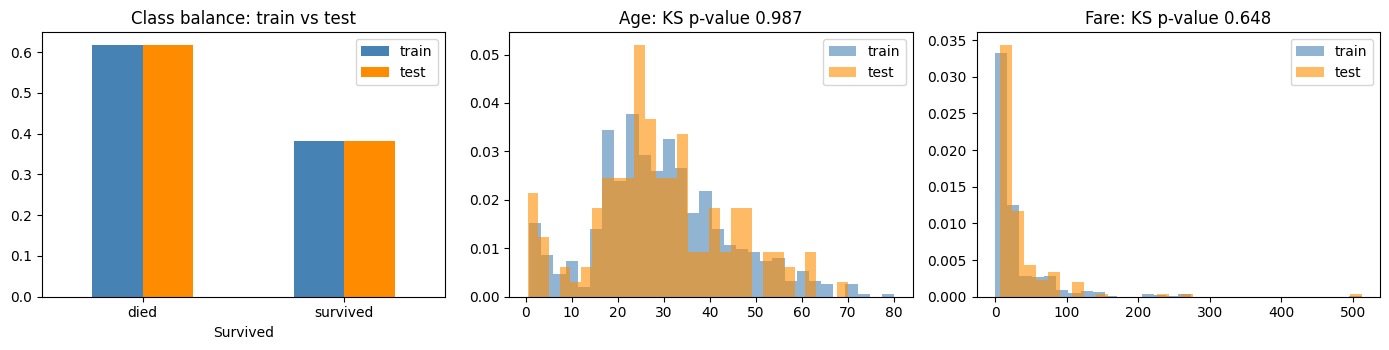

A high KS p-value means we cannot distinguish the two distributions,
which is exactly what a healthy split looks like.


In [7]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

pd.DataFrame({"train": y_train.value_counts(normalize=True),
              "test": y_test.value_counts(normalize=True)}).plot(
    kind="bar", ax=axes[0], color=["steelblue", "darkorange"])
axes[0].set_title("Class balance: train vs test")
axes[0].set_xticklabels(["died", "survived"], rotation=0)

for ax, col in zip(axes[1:], ["Age", "Fare"]):
    ax.hist(X_train[col].dropna(), bins=30, alpha=0.6, density=True,
            color="steelblue", label="train")
    ax.hist(X_test[col].dropna(), bins=30, alpha=0.6, density=True,
            color="darkorange", label="test")
    ks = stats.ks_2samp(X_train[col].dropna(), X_test[col].dropna())
    ax.set_title(col + ": KS p-value " + str(round(ks.pvalue, 3)))
    ax.legend()
plt.tight_layout(); plt.show()

print("A high KS p-value means we cannot distinguish the two distributions,")
print("which is exactly what a healthy split looks like.")


### The validation set, and why the test set is sacred

Every time you check test performance and then change something, you are fitting to the test set through your own decisions. Do it twenty times and that 20% is no longer unseen data, it is just a slow, manual form of training. The test set should be touched **exactly once**, at the very end.

The clean solution is a three-way split: train to fit, validation to tune, test to report. Split twice, holding out the test set first.


In [8]:
X_temp, X_holdout, y_temp, y_holdout = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp,
    random_state=RANDOM_STATE)     # 0.25 of the remaining 80% gives 20% overall

print("Three-way split:")
print("  train:      ", len(X_fit), "rows (", round(len(X_fit)/len(X)*100), "%)")
print("  validation: ", len(X_val), "rows (", round(len(X_val)/len(X)*100), "%)")
print("  test:       ", len(X_holdout), "rows (",
      round(len(X_holdout)/len(X)*100), "%)")


Three-way split:
  train:       533 rows ( 60 %)
  validation:  178 rows ( 20 %)
  test:        178 rows ( 20 %)


Many practitioners replace the explicit validation set with cross-validation on the training data, which is more efficient on small datasets. We will do exactly that later, but the principle is unchanged: tune on something that is not your final test set.

### The pitfalls that quietly ruin a split

- **Splitting after feature engineering.** Compute "average fare per ticket group" across the whole dataset and that average contains test rows. Split the raw data first, then engineer.
- **Preprocessing before splitting.** Fitting a scaler or encoder on everything leaks test statistics into training. This is why every transformation in this notebook lives inside a Pipeline.
- **Feature selection before splitting.** Choosing features using the full dataset uses test labels to make a modeling decision. Same leak, subtler shape.
- **Ignoring group structure.** If several rows belong to the same user, session, or family, they must not straddle the split, or the model learns group-specific quirks that inflate the test score and help nobody in production. `GroupShuffleSplit` and `GroupKFold` keep groups intact.
- **Shuffling time-ordered data.** Random splitting lets the model see the future. Time data gets split by time, always.
- **Test sets that are too small.** Below roughly 100 samples, use cross-validation.
- **Peeking.** Even inspecting test-set summary statistics can bias your choices.

Titanic actually has group structure worth taking seriously: families share tickets and surnames, and their survival outcomes are strongly correlated because they boarded lifeboats together.


In [9]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["Ticket"]           # passengers sharing a ticket travelled together
shared = groups.map(groups.value_counts()) > 1
print("Passengers sharing a ticket with someone else:", int(shared.sum()),
      "of", len(df))

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(X, y, groups=groups))

overlap_random = len(set(groups.iloc[X_train.index]) &
                     set(groups.iloc[X_test.index]))
overlap_group = len(set(groups.iloc[tr_idx]) & set(groups.iloc[te_idx]))
print()
print("Ticket groups appearing in BOTH train and test:")
print("  plain stratified split:", overlap_random)
print("  GroupShuffleSplit:     ", overlap_group)


Passengers sharing a ticket with someone else: 342 of 889

Ticket groups appearing in BOTH train and test:
  plain stratified split: 52
  GroupShuffleSplit:      0


Dozens of travelling parties are split across both sides of the ordinary split. The model can learn "this exact family survived" from the training half and get graded on their relatives in the test half. On Titanic the effect is mild, but the identical pattern in a security dataset (many connections from one source IP, many sessions from one user) inflates test scores substantially and produces a model that fails on genuinely new users.


---
# Section 2: Fit a logistic regression

Despite the name, logistic regression is a **classifier**. The word regression refers to the machinery inside, not the job it does.

Five words that will appear often from here on:

- **Regression** predicts a number. **Classification** predicts a category.
- A **cost function** scores how wrong the model currently is. Lower is better.
- **Gradient descent** is how it improves: you are standing on a foggy hillside and cannot see the valley, but you can feel which way the ground slopes, so you take a step downhill and repeat.
- **Regularization** is the rule that stops the model getting too clever and memorizing the training data, the way a student who memorizes the practice exam aces it and then fails the real one.
- A **coefficient** is a weight showing how much one feature pushes the answer up or down.

### From linear to logistic

Linear regression outputs any number at all, so it will happily predict that an email is 340% spam. Classification needs a probability between 0 and 1. The **sigmoid** function does the conversion:

**sigma(z) = 1 / (1 + e^(-z))**

Feed it any number, get back something between 0 and 1. Logistic regression is linear regression with that one extra step on the end. The output is the probability of "yes," and a cutoff (0.5 by default) turns it into a label.


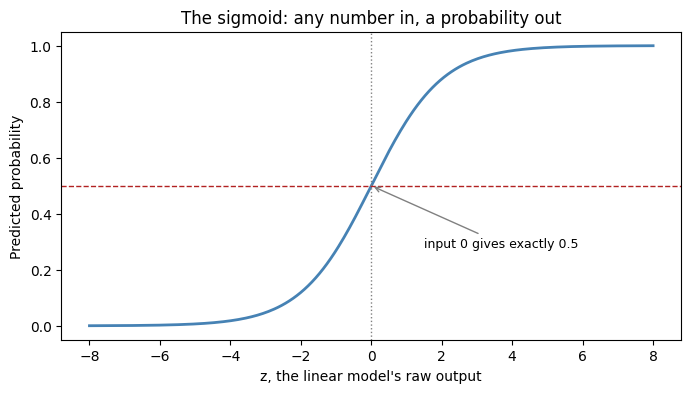

z = -4 -> probability 0.018
z = -1 -> probability 0.269
z =  0 -> probability 0.5
z =  1 -> probability 0.731
z =  4 -> probability 0.982


In [10]:
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, color="steelblue", linewidth=2)
plt.axhline(0.5, color="firebrick", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle=":", linewidth=1)
plt.title("The sigmoid: any number in, a probability out")
plt.xlabel("z, the linear model's raw output")
plt.ylabel("Predicted probability")
plt.annotate("input 0 gives exactly 0.5", xy=(0, 0.5), xytext=(1.5, 0.28),
             arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9)
plt.show()

for val in [-4, -1, 0, 1, 4]:
    print("z =", str(val).rjust(2), "-> probability",
          round(1 / (1 + np.exp(-val)), 3))


The shape is what matters: extreme inputs get pushed toward near-certainty, inputs near zero come out near 0.5. A prediction near 0.5 means the model is genuinely unsure, and that is useful information rather than a defect. A common production pattern is to route low-confidence predictions to a human analyst instead of auto-deciding. The model saying "I do not know" is a feature.

The 0.5 cutoff is a choice, not a law. In security work you might drop it to 0.3 to catch more threats and accept more false alarms. **That cutoff is a business decision, not a modeling decision**, and Section 8 treats it as one.



### Training it


In [11]:
from sklearn.linear_model import LogisticRegression

logreg = make_pipeline(LogisticRegression(C=1.0, solver="lbfgs",
                                          max_iter=1000,
                                          random_state=RANDOM_STATE))
logreg.fit(X_train, y_train)

train_acc = logreg.score(X_train, y_train)
test_acc = logreg.score(X_test, y_test)
gap = train_acc - test_acc
print("Training accuracy:", round(train_acc, 4))
print("Test accuracy:    ", round(test_acc, 4))
print("Gap:              ", round(gap, 4))
print()
if abs(gap) < 0.05:
    print("A gap this small is what healthy generalization looks like.")
if gap < 0:
    print("Note the gap is slightly NEGATIVE: the model scored a little higher")
    print("on test data than on training data. On a test set of only",
          len(y_test), "rows")
    print("that is ordinary sampling noise, not a red flag. A LARGE reversal")
    print("is a different story and usually means leakage or a broken split.")


Training accuracy: 0.8059
Test accuracy:     0.8258
Gap:               -0.0199

A gap this small is what healthy generalization looks like.
Note the gap is slightly NEGATIVE: the model scored a little higher
on test data than on training data. On a test set of only 178 rows
that is ordinary sampling noise, not a red flag. A LARGE reversal
is a different story and usually means leakage or a broken split.


Report both numbers, always. "99% accuracy" tells a stakeholder nothing. "83% training, 81% test" tells them the model is real.

### Coefficients, the superpower

Most models are opaque. This one hands you a list saying precisely what it weighted and by how much. Positive coefficients push toward survival, negative away, and larger absolute values mean more influence. That last part is **only true because we scaled the features first**, which is the trap that catches everyone once: a feature measured in millions gets a tiny coefficient and one measured in single digits gets a large one, and neither number reflects real importance.


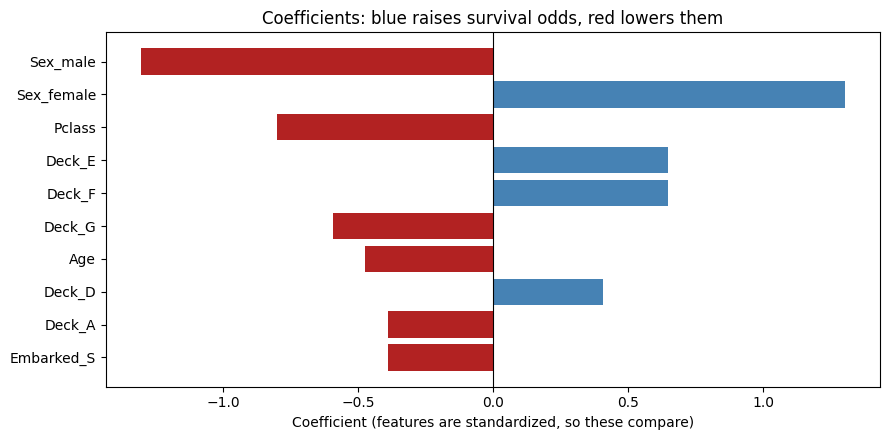

In [12]:
names = logreg.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(logreg.named_steps["model"].coef_[0], index=names)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(10)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["steelblue" if v > 0 else "firebrick" for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([n.split("__")[-1] for n in top.index])
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coefficients: blue raises survival odds, red lowers them")
ax.set_xlabel("Coefficient (features are standardized, so these compare)")
plt.tight_layout(); plt.show()


For a business audience, translate coefficients into **odds**. Exponentiating a coefficient gives the multiplier applied to the odds for a one-unit increase, which compliance officers and analysts find far more familiar than log-odds.


In [13]:
odds = np.exp(top)
for name, coef, o in zip(top.index, top.values, odds.values):
    direction = "multiplies survival odds by"
    print(name.split("__")[-1].ljust(20), "coef", str(round(coef, 3)).rjust(7),
          "->", direction, round(o, 2))


Sex_male             coef  -1.303 -> multiplies survival odds by 0.27
Sex_female           coef   1.302 -> multiplies survival odds by 3.68
Pclass               coef  -0.801 -> multiplies survival odds by 0.45
Deck_E               coef   0.648 -> multiplies survival odds by 1.91
Deck_F               coef   0.647 -> multiplies survival odds by 1.91
Deck_G               coef  -0.595 -> multiplies survival odds by 0.55
Age                  coef  -0.475 -> multiplies survival odds by 0.62
Deck_D               coef   0.407 -> multiplies survival odds by 1.5
Deck_A               coef  -0.388 -> multiplies survival odds by 0.68
Embarked_S           coef  -0.387 -> multiplies survival odds by 0.68


### The C parameter

`C` controls regularization strength, and it is **the inverse** of what most textbooks call the penalty, which trips up everyone at least once:

- **Smaller C** means stronger regularization and a simpler model
- **Larger C** means weaker regularization and a closer fit to the training data

Leave it at 1.0 to start, then cross-validate over 0.001 through 100. Section 4 does exactly that.

One more setting matters enormously in security and fraud work, where 1% positives is normal and under 0.1% is common: **`class_weight='balanced'`** tells the model to stop ignoring the rare class by weighting errors on it more heavily.


In [14]:
balanced = make_pipeline(LogisticRegression(
    C=1.0, max_iter=1000, class_weight="balanced",
    random_state=RANDOM_STATE)).fit(X_train, y_train)

from sklearn.metrics import recall_score, precision_score
for label, m in [("default", logreg), ("class_weight='balanced'", balanced)]:
    pred = m.predict(X_test)
    print(label.ljust(24), "recall:", round(recall_score(y_test, pred), 3),
          "| precision:", round(precision_score(y_test, pred), 3))


default                  recall: 0.721 | precision: 0.803
class_weight='balanced'  recall: 0.794 | precision: 0.711


Balancing trades precision for recall. On a moderately balanced problem like this the shift is small, but on 1% fraud it is the difference between a model that finds fraud and one that predicts "legitimate" forever.

One practical note before moving on: scikit-learn convergence warnings on `LogisticRegression` almost always trace back to unscaled features, which stretch the cost landscape into a long narrow valley and leave gradient descent crawling. Our features are scaled inside the pipeline, which is why no warning appears here.

**Why logistic regression matters:** it is interpretable, trains in seconds, is hard to overfit once regularization is on, and remains in production at enormous scale for fraud scoring, credit risk, ad click prediction, and medical diagnosis. Use it as your baseline, always, before trying anything fancier, because then you know whether the complexity actually bought you anything. In regulated settings interpretability is a hard requirement: when a transaction gets flagged, somebody has to explain why, and "the neural network said so" does not survive an audit.


---
# Section 3: Decision boundaries

Every classifier draws a line, a curve, or a surface separating one class from another. The **decision boundary** is where the model switches from predicting "no" to predicting "yes," which for a probabilistic model is wherever the predicted probability equals the cutoff.

The shape of that boundary tells you how complex the model is and how likely it is to overfit. Logistic regression draws a straight line. Decision trees draw rectangles. Neural networks draw anything at all.

To see them we need two dimensions, so we use `Age` and `Fare` alone. That is a real loss of information, and the accuracies below are correspondingly lower than the full model's, but the shapes are the point.


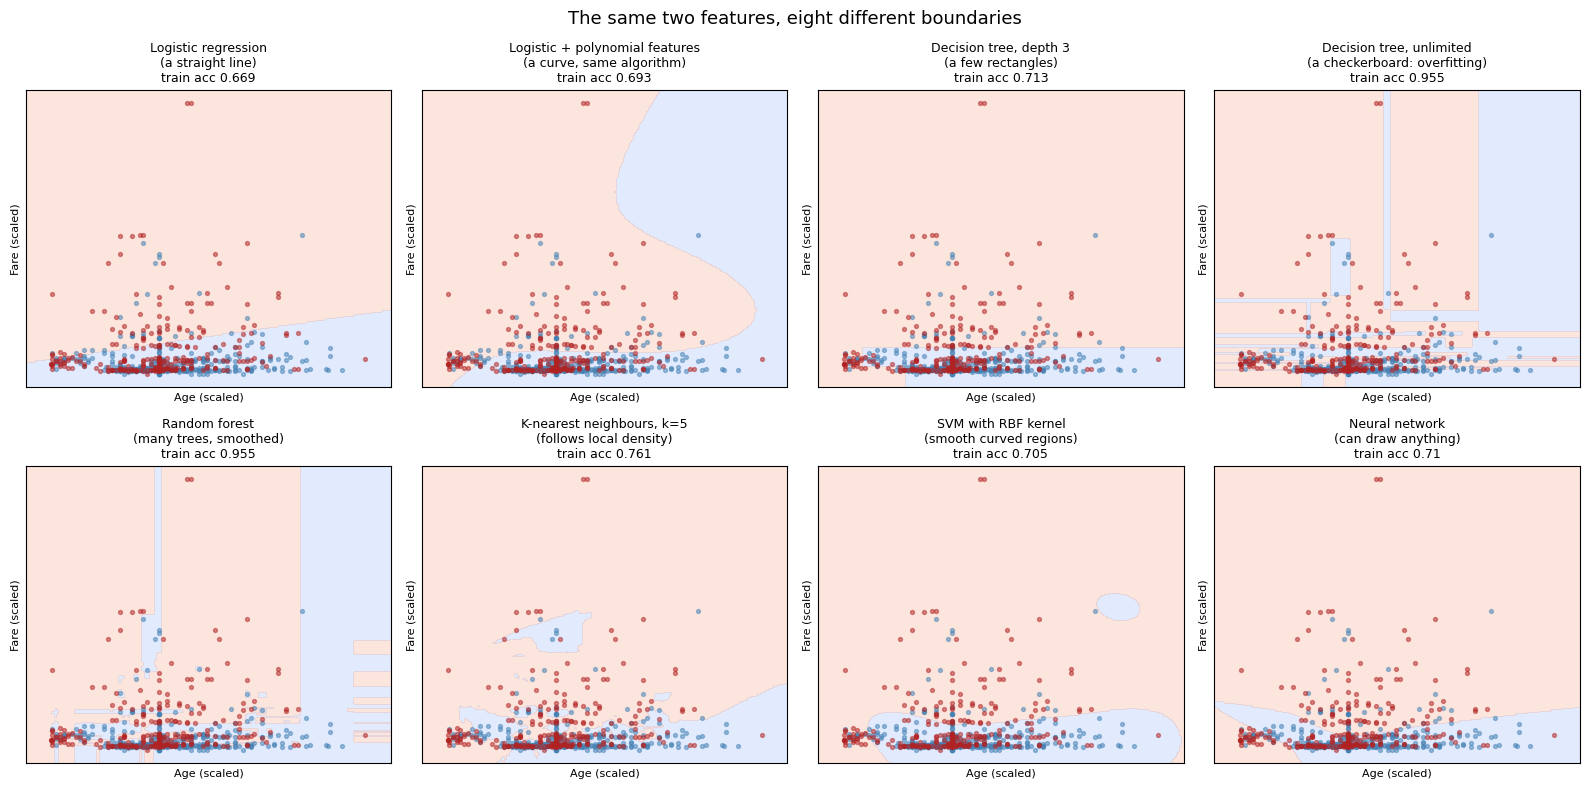

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import PolynomialFeatures

two = ["Age", "Fare"]
X2 = X_train[two].copy()
X2["Age"] = X2["Age"].fillna(X2["Age"].median())
X2s = StandardScaler().fit_transform(X2)
y2 = y_train.values

def boundary_pipeline(model):
    return Pipeline([("scale", StandardScaler()), ("model", model)])

models_2d = {
    "Logistic regression\n(a straight line)":
        LogisticRegression(random_state=RANDOM_STATE),
    "Logistic + polynomial features\n(a curve, same algorithm)":
        Pipeline([("poly", PolynomialFeatures(3)),
                  ("lr", LogisticRegression(max_iter=2000,
                                            random_state=RANDOM_STATE))]),
    "Decision tree, depth 3\n(a few rectangles)":
        DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "Decision tree, unlimited\n(a checkerboard: overfitting)":
        DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random forest\n(many trees, smoothed)":
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "K-nearest neighbours, k=5\n(follows local density)":
        KNeighborsClassifier(n_neighbors=5),
    "SVM with RBF kernel\n(smooth curved regions)":
        SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Neural network\n(can draw anything)":
        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=2000,
                      random_state=RANDOM_STATE),
}

xx, yy = np.meshgrid(np.linspace(X2s[:, 0].min() - .5, X2s[:, 0].max() + .5, 220),
                     np.linspace(X2s[:, 1].min() - .5, X2s[:, 1].max() + .5, 220))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (title, model) in zip(axes.ravel(), models_2d.items()):
    model.fit(X2s, y2)
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm", levels=1)
    ax.scatter(X2s[y2 == 0, 0], X2s[y2 == 0, 1], s=8, alpha=.5,
               color="steelblue")
    ax.scatter(X2s[y2 == 1, 0], X2s[y2 == 1, 1], s=8, alpha=.5,
               color="firebrick")
    ax.set_title(title + "\ntrain acc " + str(round(model.score(X2s, y2), 3)),
                 fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("Age (scaled)", fontsize=8)
    ax.set_ylabel("Fare (scaled)", fontsize=8)
plt.suptitle("The same two features, eight different boundaries", fontsize=13)
plt.tight_layout(); plt.show()


**Logistic regression** draws one flat cut. In two dimensions that is a line, in three a plane, in twenty a hyperplane. It is easy to explain, stable, and fast. It cannot handle curved or ring-shaped patterns, but "linear" is far more capable than it sounds: with fifty features the boundary is being pushed and pulled by all fifty at once. A spam filter with a hundred word-frequency features makes genuinely nuanced calls with a technically linear boundary.

**Logistic regression with polynomial features** is the cheapest non-linearity available. Add squared terms and feature products, run the same algorithm, and the boundary curves in the original space. Non-linearity without leaving familiar territory.

**The depth-3 tree** carves the space into a handful of rectangles, because every split asks a question about one feature at a time. **The unlimited tree** carves it into a checkerboard of tiny rectangles, each one capturing a few individual passengers. Its training accuracy is near-perfect and that is precisely the problem: overfitting made visible rather than theoretical.

**The random forest** averages many such trees, which smooths the boundary considerably while retaining flexibility.

**K-nearest neighbours** has no equation at all; the boundary simply follows local density, which makes it sensitive to noise and completely dependent on scaling.

**The RBF-kernel SVM** finds a straight boundary in a transformed space, which looks like a smooth curve back in ours.

**The neural network** can draw essentially any shape given enough data, and on tabular problems like this one that flexibility mostly buys it more ways to memorize.

**The tradeoff to carry forward: flexibility is not free.** Every bit of extra freedom is extra room to memorize noise.

### The feature space matters more than the algorithm

The boundary is drawn in whatever space your features define, so changing the features moves it. Better features make the boundary simpler: log transforms straighten curved relationships, combining two features captures effects neither shows alone, and domain knowledge encoded as a feature beats algorithmic cleverness almost every time. Time spent on features pays better than time spent on algorithms.

The honest question to ask about your own data is whether it is roughly **linearly separable**, and for most tabular problems in finance and security the answer is yes. The cases that truly demand curved boundaries tend to be perceptual: images, audio, raw signals. Not spreadsheets.


---
# Section 4: Overfitting and underfitting

This is the central tension in all of machine learning, and every modeling decision is a tradeoff between two failure modes.

- **Underfitting**: the model is too simple to capture the real pattern. Training accuracy low, test accuracy low. Both bad, but honest failure. It looks bad immediately and nobody ships it.
- **Overfitting**: the model memorized the training data, noise included. Training accuracy high, test accuracy much lower. This is the dangerous one, because it looks like success right up until production.

In formal terms, **bias** is being wrong because your model is too simple, and **variance** is being unstable because your model is too twitchy. The whole diagnosis reduces to two numbers: both low means underfitting, training high with test low means overfitting, both high and close means you are done.


In [16]:
from sklearn.dummy import DummyClassifier

diagnostics = {
    "Underfit: predict the majority class":
        DummyClassifier(strategy="most_frequent"),
    "Underfit: a single decision stump":
        DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    "Good fit: logistic regression":
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Good fit: pruned tree, depth 4":
        DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Overfit: unpruned decision tree":
        DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Overfit: 1-nearest neighbour":
        KNeighborsClassifier(n_neighbors=1),
}

rows = []
for name, model in diagnostics.items():
    pipe = make_pipeline(model).fit(X_train, y_train)
    tr, te = pipe.score(X_train, y_train), pipe.score(X_test, y_test)
    rows.append({"model": name, "train": round(tr, 3), "test": round(te, 3),
                 "gap": round(tr - te, 3)})
pd.DataFrame(rows).set_index("model")


,train,test,gap
model,,,
Underfit: predict the majority class,0.617,0.618,-0.001
Underfit: a single decision stump,0.790,0.770,0.021
Good fit: logistic regression,0.806,0.826,-0.020
"Good fit: pruned tree, depth 4",0.831,0.803,0.028
Overfit: unpruned decision tree,0.989,0.764,0.225
Overfit: 1-nearest neighbour,0.980,0.747,0.233


The unpruned tree and the 1-nearest-neighbour model both score essentially 100% on training data. Neither has learned anything general; they have memorized. A 1-NN model's nearest neighbour for any training point is itself, which makes perfect training accuracy structurally guaranteed and completely meaningless.

**No model should hit 100% accuracy on real noisy data.** If yours does, you have not built something excellent, you have built something that memorized. Overfitting is not the model being too smart. It is the model being unable to tell signal from noise.

The squint test is the visual version: blur your eyes at a scatter plot, and whatever pattern survives the squinting is the signal. The rest is noise.

### Complexity sweeps

Rather than guessing, sweep the knob that controls complexity and watch both curves.


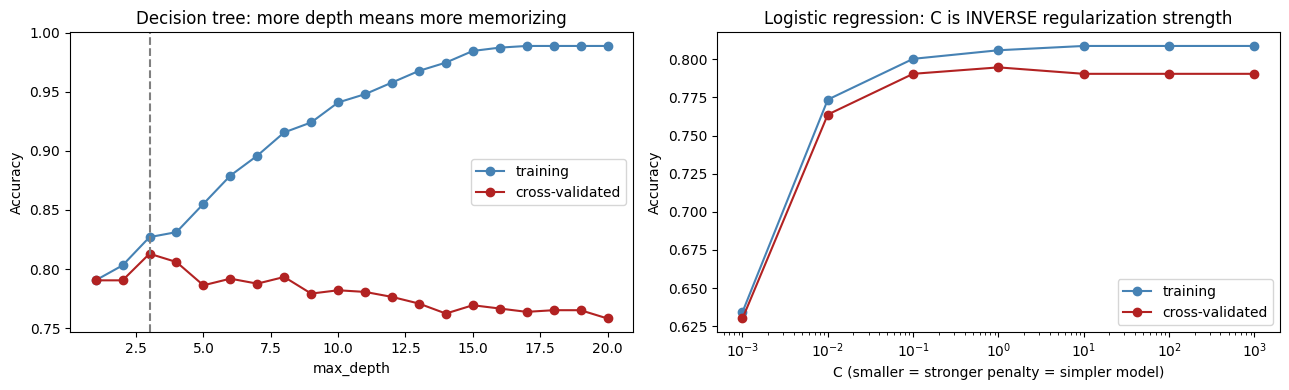

Best tree depth: 3 | best C: 1


In [17]:
from sklearn.model_selection import cross_val_score

depths = range(1, 21)
tree_train, tree_val = [], []
for d in depths:
    p = make_pipeline(DecisionTreeClassifier(max_depth=d,
                                             random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    tree_train.append(p.score(X_train, y_train))
    tree_val.append(cross_val_score(p, X_train, y_train, cv=5).mean())

Cs = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
lr_train, lr_val = [], []
for c in Cs:
    p = make_pipeline(LogisticRegression(C=c, max_iter=5000,
                                         random_state=RANDOM_STATE))
    p.fit(X_train, y_train)
    lr_train.append(p.score(X_train, y_train))
    lr_val.append(cross_val_score(p, X_train, y_train, cv=5).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(depths, tree_train, "o-", color="steelblue", label="training")
axes[0].plot(depths, tree_val, "o-", color="firebrick", label="cross-validated")
axes[0].axvline(int(np.argmax(tree_val)) + 1, color="gray", linestyle="--")
axes[0].set_title("Decision tree: more depth means more memorizing")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].semilogx(Cs, lr_train, "o-", color="steelblue", label="training")
axes[1].semilogx(Cs, lr_val, "o-", color="firebrick", label="cross-validated")
axes[1].set_title("Logistic regression: C is INVERSE regularization strength")
axes[1].set_xlabel("C (smaller = stronger penalty = simpler model)")
axes[1].set_ylabel("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

print("Best tree depth:", int(np.argmax(tree_val)) + 1,
      "| best C:", Cs[int(np.argmax(lr_val))])


The tree panel is textbook: the two curves separate steadily as depth grows, training climbing toward 1.0 while validation flattens and then declines. That widening gap **is** overfitting, drawn as a picture.

The logistic regression panel shows the opposite hazard on its left edge. At C = 0.001 the penalty is so strong that the model is crushed into underfitting, with both curves low together.

### Regularization: L1 versus L2

Without a penalty the optimizer will happily assign enormous coefficients to squeeze out a little extra training accuracy, and that model breaks on anything slightly different.

- **L2 (Ridge)** shrinks all coefficients toward zero but keeps them all. Everyone's vote gets quieter. This is the default.
- **L1 (Lasso)** drives unhelpful coefficients to exactly zero, removing those features entirely. Some voters get removed from the room. This gives you feature selection for free, which is a real benefit when you started with hundreds of candidates.


In [18]:
l2 = make_pipeline(LogisticRegression(penalty="l2", C=0.1, max_iter=5000,
                                      random_state=RANDOM_STATE)
                   ).fit(X_train, y_train)
l1 = make_pipeline(LogisticRegression(penalty="l1", C=0.1, solver="liblinear",
                                      random_state=RANDOM_STATE)
                   ).fit(X_train, y_train)

names = l2.named_steps["preprocess"].get_feature_names_out()
compare = pd.DataFrame({
    "L2 (Ridge)": l2.named_steps["model"].coef_[0],
    "L1 (Lasso)": l1.named_steps["model"].coef_[0]},
    index=[n.split("__")[-1] for n in names]).round(3)

print("Coefficients driven to exactly zero:")
print("  L2:", int((compare['L2 (Ridge)'] == 0).sum()), "of", len(compare))
print("  L1:", int((compare['L1 (Lasso)'] == 0).sum()), "of", len(compare),
      "<- L1 performed feature selection automatically")
print()
compare.head(12)


Coefficients driven to exactly zero:
  L2: 0 of 22
  L1: 15 of 22 <- L1 performed feature selection automatically



,L2 (Ridge),L1 (Lasso)
Age,-0.385,-0.259
Fare,0.148,0.095
SibSp,-0.137,-0.056
Parch,-0.025,0.000
FamilySize,-0.104,-0.091
Sex_female,1.081,2.218
Sex_male,-1.081,0.000
Embarked_C,0.047,0.000
Embarked_Q,0.219,0.000
Embarked_S,-0.265,0.000


Elastic Net blends the two penalties and exists if you need it.

### Learning curves

The complexity sweep answers "is my model the right size?" A **learning curve** answers a different and more expensive question: **should I collect more data, or change my model?**


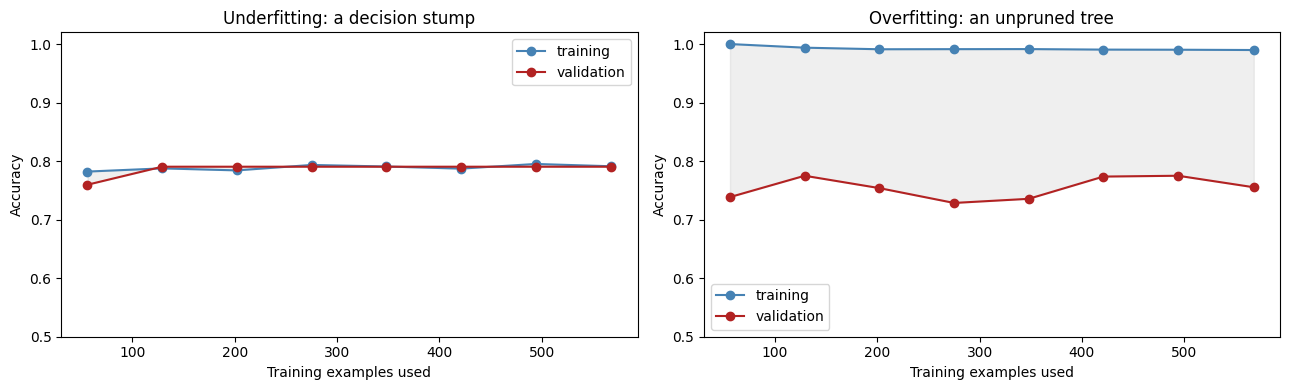

In [19]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
curves = [("Underfitting: a decision stump",
           DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)),
          ("Overfitting: an unpruned tree",
           DecisionTreeClassifier(random_state=RANDOM_STATE))]

for ax, (title, model) in zip(axes, curves):
    sizes, train_sc, val_sc = learning_curve(
        make_pipeline(model), X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=RANDOM_STATE)
    ax.plot(sizes, train_sc.mean(axis=1), "o-", color="steelblue",
            label="training")
    ax.plot(sizes, val_sc.mean(axis=1), "o-", color="firebrick",
            label="validation")
    ax.fill_between(sizes, val_sc.mean(axis=1), train_sc.mean(axis=1),
                    alpha=0.12, color="gray")
    ax.set_title(title); ax.set_xlabel("Training examples used")
    ax.set_ylabel("Accuracy"); ax.set_ylim(0.5, 1.02); ax.legend()
plt.tight_layout(); plt.show()


Two very different diagnoses from the same chart type:

- **Left, underfitting.** Both curves are flat, low, and close together. The model has learned everything it can from this data. Collecting more would be wasted effort; you need better features or a richer model.
- **Right, overfitting.** Training sits high, validation well below, with a visible gap that narrows as data grows. Here more data genuinely helps, which is usually the easier problem to have.

A learning curve communicates far more to a stakeholder than a single accuracy number ever will.

**Fixing each failure:** for overfitting, more data first if you can get it, then regularization, then simplifying the model. For underfitting, reach for better features before reaching for a bigger algorithm, since it is usually a feature problem rather than a model problem.


---
# Section 5: The algorithm zoo

Logistic regression was our baseline. Now the same problem, the same preprocessing, the same split, thirteen different algorithms. The goal is not to crown a winner. It is to see how the tradeoffs differ, because in practice you will choose on interpretability, training cost, and maintenance burden far more often than on a third decimal place of accuracy.


In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (GradientBoostingClassifier,
                              HistGradientBoostingClassifier,
                              ExtraTreesClassifier, VotingClassifier,
                              StackingClassifier, AdaBoostClassifier)
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score)

zoo = {
    "Dummy (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(max_iter=1000,
                                              random_state=RANDOM_STATE),
    "Linear discriminant analysis": LinearDiscriminantAnalysis(),
    "Gaussian naive Bayes": GaussianNB(),
    "K-nearest neighbours (k=15)": KNeighborsClassifier(n_neighbors=15),
    "Linear SVM": SVC(kernel="linear", probability=True,
                      random_state=RANDOM_STATE),
    "RBF-kernel SVM": SVC(kernel="rbf", probability=True,
                          random_state=RANDOM_STATE),
    "Decision tree (depth 4)": DecisionTreeClassifier(
        max_depth=4, random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(n_estimators=300,
                                            random_state=RANDOM_STATE),
    "Extra trees": ExtraTreesClassifier(n_estimators=300,
                                        random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=200,
                                   random_state=RANDOM_STATE),
    "Gradient boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE),
    "Histogram gradient boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE),
    "Neural network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32),
                                          max_iter=2000,
                                          random_state=RANDOM_STATE),
}

# XGBoost and LightGBM are the industry standards for tabular boosting and are
# preinstalled in Colab. HistGradientBoosting above is scikit-learn's own
# implementation of the same idea and behaves very similarly.
try:
    from xgboost import XGBClassifier
    zoo["XGBoost"] = XGBClassifier(eval_metric="logloss",
                                   random_state=RANDOM_STATE)
except ImportError:
    print("xgboost not installed here, skipping it (Colab has it).")

results = []
fitted = {}
for name, model in zoo.items():
    pipe = make_pipeline(model)
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    fitted[name] = pipe
    results.append({
        "model": name,
        "train acc": round(pipe.score(X_train, y_train), 3),
        "test acc": round(accuracy_score(y_test, pred), 3),
        "gap": round(pipe.score(X_train, y_train) - accuracy_score(y_test, pred), 3),
        "F1": round(f1_score(y_test, pred), 3),
        "AUC": round(roc_auc_score(y_test, proba), 3),
        "AP": round(average_precision_score(y_test, proba), 3),
        "fit sec": round(fit_time, 3)})

leaderboard = pd.DataFrame(results).set_index("model").sort_values(
    "AUC", ascending=False)
leaderboard


,train acc,test acc,gap,F1,AUC,AP,fit sec
model,,,,,,,
AdaBoost,0.824,0.820,0.004,0.765,0.878,0.832,0.420
Logistic regression,0.806,0.826,-0.020,0.760,0.862,0.819,0.024
Gradient boosting,0.907,0.831,0.076,0.776,0.854,0.835,0.198
Linear discriminant analysis,0.812,0.815,-0.003,0.744,0.853,0.810,0.049
RBF-kernel SVM,0.833,0.809,0.024,0.730,0.853,0.794,0.093
Decision tree (depth 4),0.831,0.803,0.028,0.715,0.851,0.795,0.014
K-nearest neighbours (k=15),0.823,0.803,0.019,0.737,0.842,0.783,0.014
Random forest,0.989,0.787,0.202,0.712,0.835,0.809,0.610
Neural network (MLP),0.916,0.826,0.090,0.763,0.833,0.815,1.490


Three things in that table deserve more attention than the ordering.

**The spread at the top is tiny.** The gap between the best model and logistic regression is usually a couple of points of AUC, often within the noise of a single split. We will confirm that properly with cross-validation in the next section, because a leaderboard built on one split is exactly the unreliable single number this module keeps warning about.

**The `gap` column is the interesting one.** Models with near-perfect training accuracy and mediocre test accuracy are memorizing. That column, not the accuracy column, is where you look first.

**The dummy classifier is not a joke entry.** It is the number every other model has to beat before anyone is allowed to be impressed.


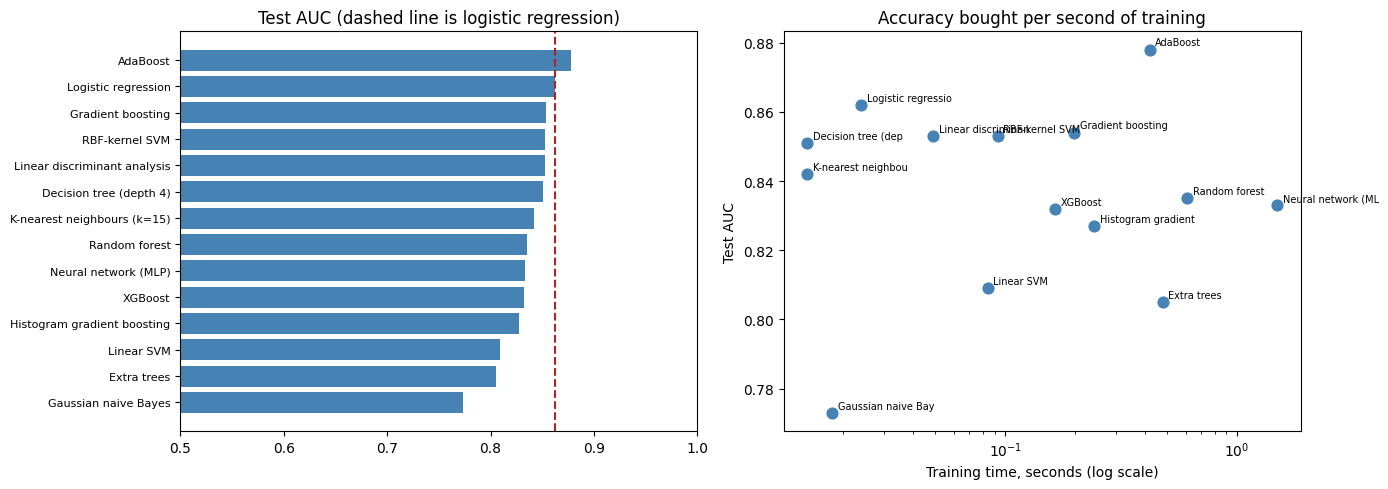

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lb = leaderboard.drop(index="Dummy (majority class)")

order = lb.sort_values("AUC")
axes[0].barh(range(len(order)), order["AUC"], color="steelblue")
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(order.index, fontsize=8)
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(leaderboard.loc["Logistic regression", "AUC"],
                color="firebrick", linestyle="--")
axes[0].set_title("Test AUC (dashed line is logistic regression)")

axes[1].scatter(lb["fit sec"], lb["AUC"], s=60, color="steelblue")
for name, row in lb.iterrows():
    axes[1].annotate(name[:18], (row["fit sec"], row["AUC"]),
                     fontsize=7, xytext=(4, 3), textcoords="offset points")
axes[1].set_xscale("log")
axes[1].set_xlabel("Training time, seconds (log scale)")
axes[1].set_ylabel("Test AUC")
axes[1].set_title("Accuracy bought per second of training")
plt.tight_layout(); plt.show()


### What each algorithm is actually good and bad at

| Algorithm | Boundary | Strengths | Weaknesses | Reach for it when |
|---|---|---|---|---|
| **Logistic regression** | Linear | Interpretable coefficients, fast, hard to overfit with regularization, calibrated probabilities | Cannot capture interactions or curves unless you engineer them | Always, as your baseline. Often it is also the answer |
| **Linear discriminant analysis** | Linear | Very fast, works well on small data, no tuning | Assumes each class is Gaussian with equal covariance | Small datasets with roughly normal features |
| **Gaussian naive Bayes** | Curved | Extremely fast, works with tiny data, handles many features | Assumes features are independent, which is almost never true; probabilities are poorly calibrated | Text classification, spam, a fast first look |
| **K-nearest neighbours** | Follows local density | No training phase, captures irregular shapes, trivially simple | Slow at prediction, breaks without scaling, degrades badly in high dimensions | Small, low-dimensional data with meaningful distances |
| **Linear SVM** | Linear, max-margin | Robust with many features, effective on text | No native probabilities, slow to train on large data | High-dimensional sparse data |
| **RBF-kernel SVM** | Smooth curves | Powerful on medium datasets, elegant with non-linear patterns | Scales poorly past tens of thousands of rows, needs tuning, opaque | Medium data with genuine curvature |
| **Decision tree** | Rectangles | Fully interpretable, no scaling needed, handles mixed types | Overfits badly alone, unstable to small data changes | Explaining a rule set to non-technical stakeholders |
| **Random forest** | Many rectangles averaged | Strong out of the box, resists overfitting, gives feature importances | Larger memory footprint, less interpretable than one tree | A strong default when interpretability is secondary |
| **Extra trees** | Like random forest, more random | Faster to train, sometimes generalizes better | Slightly less accurate on structured signal | A quick, high-variance-reducing alternative |
| **AdaBoost** | Weighted stumps | Simple, few hyperparameters, good with weak learners | Sensitive to noise and outliers because it chases hard cases | Clean data with a modest number of features |
| **Gradient boosting** | Additive rectangles | Usually top-tier on tabular data | Slow to train, needs tuning, easy to overfit | Squeezing out maximum tabular accuracy |
| **Histogram gradient boosting / XGBoost / LightGBM** | Same, optimized | State of the art on tabular problems, handles NaN natively, fast on large data | Many hyperparameters, opaque, heavier to deploy | Large tabular datasets where accuracy is the priority |
| **Neural network (MLP)** | Anything | Universal approximator, excels on images, audio, and text | Needs lots of data, sensitive to scaling, slow, opaque | Perceptual data. On tabular problems it usually loses to boosting |

### Ensembles: combining several models

Two ways to blend. **Voting** averages the predictions of several models directly. **Stacking** trains a small meta-model to learn how much to trust each base model.


In [22]:
voting = make_pipeline(VotingClassifier(
    estimators=[("lr", LogisticRegression(max_iter=1000,
                                          random_state=RANDOM_STATE)),
                ("rf", RandomForestClassifier(n_estimators=300,
                                              random_state=RANDOM_STATE)),
                ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE))],
    voting="soft")).fit(X_train, y_train)

stacking = make_pipeline(StackingClassifier(
    estimators=[("lr", LogisticRegression(max_iter=1000,
                                          random_state=RANDOM_STATE)),
                ("rf", RandomForestClassifier(n_estimators=300,
                                              random_state=RANDOM_STATE)),
                ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE))],
    final_estimator=LogisticRegression(),
    cv=5)).fit(X_train, y_train)

for name, m in [("Soft voting ensemble", voting),
                ("Stacking ensemble", stacking)]:
    proba = m.predict_proba(X_test)[:, 1]
    fitted[name] = m
    print(name.ljust(22), "test acc",
          round(m.score(X_test, y_test), 3),
          "| AUC", round(roc_auc_score(y_test, proba), 3))
print()
print("Logistic regression alone:  test acc",
      leaderboard.loc["Logistic regression", "test acc"],
      "| AUC", leaderboard.loc["Logistic regression", "AUC"])


Soft voting ensemble   test acc 0.843 | AUC 0.861
Stacking ensemble      test acc 0.843 | AUC 0.859

Logistic regression alone:  test acc 0.826 | AUC 0.862


Compare those numbers against logistic regression alone carefully. The ensembles pick up a point or two of accuracy, and their AUC lands essentially level with the single linear model. For that you now have three models to train, deploy, monitor, and explain instead of one. Ensembles often do edge out their components, but "often" is not "always," and the only way to know which case you are in is to measure.

### The lesson of the zoo

On this dataset a linear model trained in milliseconds finishes near the top of the table, ahead of several boosting and ensemble methods that took ten to a hundred times longer to fit. That is not a quirk of Titanic; it is the normal result on clean tabular data with well-engineered features. **The 1% rule** captures the right instinct: a tiny accuracy gain rarely justifies a model nobody can explain or debug.

So the real selection criteria are usually:

1. **Does it beat the baseline meaningfully?** If not, the problem is your features or your data, and no algorithm will rescue it.
2. **Do you need to explain individual predictions?** Regulated domains make this non-negotiable, and it eliminates most of the table.
3. **What does it cost to keep running?** Training time, prediction latency, memory, and the ongoing burden of monitoring something opaque.
4. **How much data do you have?** Neural networks need a lot. Naive Bayes and LDA work on very little.
5. **Is the extra accuracy real?** One split cannot tell you. Cross-validation can, which is next.


---
# Section 6: Cross-validation

A single train/test split gives one number, and that number depends on luck. An unlucky draw can make a good model look bad or a bad model look good, and nothing tells you which happened.

**K-fold** cross-validation splits the data into k groups, trains on all but one, tests on the leftover, and rotates. Every data point ends up in the test set exactly once, and you get k estimates instead of one. The average is more trustworthy, and the spread tells you how stable the model actually is.


In [23]:
from sklearn.model_selection import (KFold, StratifiedKFold,
                                     RepeatedStratifiedKFold, LeaveOneOut,
                                     cross_validate, GroupKFold,
                                     StratifiedGroupKFold, TimeSeriesSplit)

pipe = make_pipeline(LogisticRegression(max_iter=1000,
                                        random_state=RANDOM_STATE))
scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")

print("Fold scores:", scores.round(4))
print("Mean:", round(scores.mean(), 4), "+/-", round(scores.std(), 4))
print("Approximate 95% confidence interval:",
      round(scores.mean() - 2 * scores.std(), 3), "to",
      round(scores.mean() + 2 * scores.std(), 3))


Fold scores: [0.7921 0.7921 0.7753 0.7865 0.8136]
Mean: 0.7919 +/- 0.0124
Approximate 95% confidence interval: 0.767 to 0.817


Report the spread, not just the mean. A model averaging 85% plus or minus 2% is a completely different proposition from one averaging 85% plus or minus 15%, and the single number hides that entirely.

Inspect the individual folds too. Scores of [0.92, 0.91, 0.93, 0.90, 0.72] average to a respectable 0.876, but the real story is one fold performing terribly, and that fold usually points at a data quality problem or an unusual cluster of examples.

### Stratified K-fold

Same argument as stratified splitting: with rare classes, plain K-fold will eventually hand you a fold containing zero positive examples. scikit-learn already stratifies classification problems inside `cross_val_score` by default, which is a good default to know about, but be explicit when it matters.


In [24]:
plain = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

y_imb_arr = y_imb.values
X_imb = imb[NUMERIC + CATEGORICAL + PASSTHROUGH]

print("Positive examples per test fold at a 1% positive rate:")
for name, splitter in [("plain KFold", plain), ("StratifiedKFold", strat)]:
    counts = [int(y_imb_arr[te].sum())
              for _, te in splitter.split(X_imb, y_imb_arr)]
    print(" ", name.ljust(17), counts)


Positive examples per test fold at a 1% positive rate:
  plain KFold       [2, 3, 0, 1, 3]
  StratifiedKFold   [2, 2, 2, 1, 2]


### Choosing K

K is a bias-variance tradeoff for the **performance estimate**, not for the model itself.

- **K=2** trains on only half the data each time, so the estimate is pessimistically biased
- **K=5** is the good default: trains on 80% each fold at reasonable cost
- **K=10** is slightly less biased, trains on 90%, and costs twice as much as K=5
- **K=N** is leave-one-out, covered below

Use K=5 for exploration and K=10 or repeated 5-fold for final model selection.

### Repeated cross-validation

Even K-fold results shift slightly depending on how folds were randomly assigned. Repeated K-fold reruns the whole process with different shuffles, giving a very stable estimate. It is what you want when comparing two models that are close together.


In [25]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=6,
                               random_state=RANDOM_STATE)

contenders = {
    "Logistic regression": LogisticRegression(max_iter=1000,
                                              random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(n_estimators=300,
                                            random_state=RANDOM_STATE),
    "Gradient boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE),
}

print("30 evaluations each (5 folds x 6 repeats), scored by AUC:")
for name, model in contenders.items():
    s = cross_val_score(make_pipeline(model), X, y, cv=rskf, scoring="roc_auc")
    print(" ", name.ljust(22), round(s.mean(), 4), "+/-", round(s.std(), 4))


30 evaluations each (5 folds x 6 repeats), scored by AUC:
  Logistic regression    0.8526 +/- 0.0255
  Random forest          0.8567 +/- 0.0283
  Gradient boosting      0.8701 +/- 0.029


Now compare that with the single-split leaderboard from Section 5. The ordering may well differ, and the margins that looked decisive on one split turn out to be inside the noise band. This is the whole argument for cross-validation in one comparison: repeated CV gives you the statistical power to tell a real difference from a lucky one.

### Train and test scores per fold

`cross_validate` with `return_train_score=True` gives the overfitting diagnostic on every fold, not just an average.


In [26]:
cv_results = cross_validate(
    make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    X, y, cv=5, scoring="accuracy", return_train_score=True)

print("Unpruned decision tree")
print("  train folds:", cv_results["train_score"].round(3))
print("  test folds: ", cv_results["test_score"].round(3))
print("  mean gap:   ", round((cv_results["train_score"] -
                               cv_results["test_score"]).mean(), 3),
      "<- severe overfitting, visible on every single fold")


Unpruned decision tree
  train folds: [0.987 0.992 0.987 0.989 0.986]
  test folds:  [0.719 0.775 0.809 0.77  0.814]
  mean gap:    0.211 <- severe overfitting, visible on every single fold


### Leave-one-out

LOOCV sets K equal to the number of samples: train on N-1 rows, test on 1, repeat N times. It squeezes maximum value from training data, which matters when every labeled example is precious, such as small labeled attack datasets in security research.

Two catches. The cost is N model trainings, manageable for logistic regression and often prohibitive for forests or neural networks. And counterintuitively, because the training sets overlap almost completely, the individual estimates are highly correlated and LOOCV variance can exceed that of 10-fold. It is best suited to datasets under about 100 samples.


In [27]:
small = X.sample(120, random_state=RANDOM_STATE)
small_y = y.loc[small.index]

t0 = time.perf_counter()
loo_scores = cross_val_score(pipe, small, small_y, cv=LeaveOneOut())
loo_time = time.perf_counter() - t0

t0 = time.perf_counter()
tenfold = cross_val_score(pipe, small, small_y, cv=10)
ten_time = time.perf_counter() - t0

print("On a 120-row subsample:")
print("  LOOCV:  ", len(loo_scores), "model fits,",
      round(loo_time, 2), "sec, mean", round(loo_scores.mean(), 4))
print("  10-fold:", 10, "model fits,",
      round(ten_time, 2), "sec, mean", round(tenfold.mean(), 4),
      "+/-", round(tenfold.std(), 4))
print()
print("LOOCV scores are all 0 or 1 individually, since each test set is one")
print("point, so only the average carries information.")


On a 120-row subsample:
  LOOCV:   120 model fits, 4.27 sec, mean 0.7917
  10-fold: 10 model fits, 0.41 sec, mean 0.8083 +/- 0.1121

LOOCV scores are all 0 or 1 individually, since each test set is one
point, so only the average carries information.


### Cross-validation with pipelines

If you preprocess before cross-validating, the scaler and imputer have already seen the test folds, and those folds are no longer unseen. Every model in this notebook has been wrapped in a Pipeline for exactly this reason, so each fold independently fits preprocessing on its own training portion.

**The rule: anything that learns from data must live inside the pipeline.** Imputers, encoders, scalers, feature selectors, PCA, all of it.


In [28]:
from sklearn.preprocessing import StandardScaler as SS

# The wrong way, shown so the difference is concrete
leaky_X = pd.DataFrame(
    SS().fit_transform(X[NUMERIC].fillna(X[NUMERIC].median())),
    columns=NUMERIC)                       # fitted on ALL the data
leaky = cross_val_score(LogisticRegression(max_iter=1000), leaky_X, y,
                        cv=5, scoring="roc_auc").mean()

clean = cross_val_score(
    Pipeline([("impute", SimpleImputer(strategy="median")),
              ("scale", SS()),
              ("model", LogisticRegression(max_iter=1000))]),
    X[NUMERIC], y, cv=5, scoring="roc_auc").mean()

print("Preprocessing fitted on everything (leaky):", round(leaky, 4))
print("Preprocessing inside the pipeline (honest):", round(clean, 4))
print()
print("The difference is small here because scaling leaks only mild")
print("information. With target encoding or feature selection the same")
print("mistake can inflate scores by ten points or more.")


Preprocessing fitted on everything (leaky): 0.6931
Preprocessing inside the pipeline (honest): 0.6925

The difference is small here because scaling leaks only mild
information. With target encoding or feature selection the same
mistake can inflate scores by ten points or more.


### Grouped cross-validation

The group problem from Section 1, now applied to folds. `GroupKFold` keeps every member of a group inside one fold, and `StratifiedGroupKFold` respects group boundaries and class proportions simultaneously, which is the right tool for per-user or per-device security data with class imbalance.


In [29]:
gkf = GroupKFold(n_splits=5)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True,
                            random_state=RANDOM_STATE)

standard = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean()
grouped = cross_val_score(pipe, X, y, cv=gkf, groups=df["Ticket"],
                          scoring="roc_auc").mean()
strat_grouped = cross_val_score(pipe, X, y, cv=sgkf, groups=df["Ticket"],
                                scoring="roc_auc").mean()

print("Standard 5-fold AUC:        ", round(standard, 4))
print("GroupKFold by ticket:       ", round(grouped, 4))
print("StratifiedGroupKFold:       ", round(strat_grouped, 4))
print()
print("The grouped estimate is the honest one, because in production the")
print("model meets families it has never seen any member of. On Titanic the")
print("three numbers land close together, since the model leans on class, sex,")
print("and fare rather than memorizing specific families. On per-user or")
print("per-device security data the grouped number is often much lower, and")
print("that drop is the inflation the ordinary split was hiding.")


Standard 5-fold AUC:         0.8482
GroupKFold by ticket:        0.8489
StratifiedGroupKFold:        0.8487

The grouped estimate is the honest one, because in production the
model meets families it has never seen any member of. On Titanic the
three numbers land close together, since the model leans on class, sex,
and fare rather than memorizing specific families. On per-user or
per-device security data the grouped number is often much lower, and
that drop is the inflation the ordinary split was hiding.


### Time-series cross-validation

Everything above assumes data points are independent and shuffling is harmless. Time-series data violates that completely: security logs, network traffic, and sensor readings all have timestamps where order matters. Random splitting mixes past and future, so the model sees the future during training. That is **temporal leakage**, and it produces offline numbers that collapse in production.

`TimeSeriesSplit` respects the arrow of time. Titanic has no timestamps, so we simulate a stream of boarding events to demonstrate the mechanics.


In [30]:
stream = df.copy()
stream["event_time"] = pd.date_range("2026-01-01", periods=len(stream),
                                     freq="h")
stream = stream.sort_values("event_time")     # TimeSeriesSplit does NOT sort
X_stream = stream[NUMERIC + CATEGORICAL + PASSTHROUGH]
y_stream = stream["Survived"]

tscv = TimeSeriesSplit(n_splits=5)
print("Expanding window (the default): training always precedes testing")
for i, (tr, te) in enumerate(tscv.split(X_stream), 1):
    print("  fold", i, "train rows", str(len(tr)).rjust(3),
          "[0 to", str(tr[-1]).rjust(3) + "]",
          "-> test rows", str(len(te)).rjust(3),
          "[" + str(te[0]), "to", str(te[-1]) + "]")

ts_scores = cross_val_score(pipe, X_stream, y_stream, cv=tscv,
                            scoring="roc_auc")
print("\nAUC per fold:", ts_scores.round(3),
      "| mean", round(ts_scores.mean(), 3))


Expanding window (the default): training always precedes testing
  fold 1 train rows 149 [0 to 148] -> test rows 148 [149 to 296]
  fold 2 train rows 297 [0 to 296] -> test rows 148 [297 to 444]
  fold 3 train rows 445 [0 to 444] -> test rows 148 [445 to 592]
  fold 4 train rows 593 [0 to 592] -> test rows 148 [593 to 740]
  fold 5 train rows 741 [0 to 740] -> test rows 148 [741 to 888]

AUC per fold: [0.797 0.88  0.827 0.85  0.865] | mean 0.844


Improving scores across folds are a good sign: later folds train on more history, so the model is benefiting from accumulated data.

Two variations matter in production.

**Expanding versus sliding window.** The default expands the training set each fold, which suits data where older observations remain relevant. A **sliding** window keeps the training set a fixed size and moves it forward, which suits **concept drift**, where old data actively hurts. In security this is real: attack techniques evolve and normal behavior shifts, so a model trained on three years of traffic can perform worse than one trained on the most recent six months. If sliding beats expanding, drift is present.

**The gap.** In production there is usually a lag between training data and inference: you retrain weekly but predict daily. Adjacent time periods are also correlated, so testing immediately after training gives the model an unfair advantage. The `gap` parameter skips periods between train and test, producing slightly lower but more honest numbers.


In [31]:
sliding = TimeSeriesSplit(n_splits=5, max_train_size=200)
gapped = TimeSeriesSplit(n_splits=5, gap=48)      # skip 48 hours

for label, splitter in [("expanding window", tscv),
                        ("sliding window (max_train_size=200)", sliding),
                        ("expanding with a 48-period gap", gapped)]:
    s = cross_val_score(pipe, X_stream, y_stream, cv=splitter,
                        scoring="roc_auc")
    print(label.ljust(38), "AUC", round(s.mean(), 4))

print()
print("Also: never set shuffle=True on time data, sort by time first because")
print("TimeSeriesSplit splits by index position, and choose n_splits with care")
print("since the earliest folds train on very little data.")


expanding window                       AUC 0.8437
sliding window (max_train_size=200)    AUC 0.8366
expanding with a 48-period gap         AUC 0.844

Also: never set shuffle=True on time data, sort by time first because
TimeSeriesSplit splits by index position, and choose n_splits with care
since the earliest folds train on very little data.


Feature engineering must respect time too. Rolling averages and lag features have to use only past data, which means computing them inside a custom transformer in the pipeline so temporal boundaries survive cross-validation.

### Which strategy to use

| Situation | Strategy |
|---|---|
| Independent data, balanced classes | `KFold` |
| Independent data, imbalanced classes | `StratifiedKFold`, scikit-learn's default for classification |
| Group structure (users, sessions, source IPs) | `GroupKFold` or `GroupShuffleSplit` |
| Groups plus class imbalance | `StratifiedGroupKFold` |
| Time-ordered data | `TimeSeriesSplit`, never a random split |
| Very small datasets | `RepeatedStratifiedKFold` or `LeaveOneOut` |
| Unsure | `RepeatedStratifiedKFold` is robust to most scenarios |

Time ordering takes priority over everything else. A sophisticated model with the wrong CV strategy gives misleading results; a simple model with the right one gives an honest assessment.


---
# Section 7: Evaluation metrics

Model evaluation is where many ML projects go wrong, and rarely because someone miscalculated a metric. It is because they calculated the **wrong** metric.

### Accuracy pitfalls

Accuracy is correct predictions divided by total predictions. It hides critical failures on imbalanced data, and it treats every kind of error as equally bad.

Here is the demonstration, on the 1% positive-rate dataset we built earlier.


In [32]:
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=RANDOM_STATE)

dummy = make_pipeline(DummyClassifier(strategy="most_frequent")
                      ).fit(Xi_train, yi_train)
real = make_pipeline(LogisticRegression(max_iter=1000,
                                        class_weight="balanced",
                                        random_state=RANDOM_STATE)
                     ).fit(Xi_train, yi_train)

for name, m in [("Always predict 'negative'", dummy),
                ("An actual trained model", real)]:
    pred = m.predict(Xi_test)
    print(name.ljust(28),
          "accuracy", round(accuracy_score(yi_test, pred), 4),
          "| positives caught", int(((pred == 1) & (yi_test == 1)).sum()),
          "of", int(yi_test.sum()))


Always predict 'negative'    accuracy 0.9821 | positives caught 0 of 3
An actual trained model      accuracy 0.875 | positives caught 2 of 3


There it is. A model that predicts "negative" for every single row scores extremely high accuracy and catches nothing at all. This is the **accuracy paradox**: a simpler and completely useless model outscores a genuinely useful one. It is especially dangerous inside automated model selection, where optimizing for accuracy will happily choose the useless predictor.

Real-world versions of this trap, all with the same shape:

- **Cybersecurity**: attack traffic under 1% of network volume
- **Medical diagnostics**: disease prevalence of 0.1% or lower
- **Manufacturing**: defect rates below 0.5%
- **Financial fraud**: roughly 0.1% to 0.3% of transaction volume

Accuracy works when classes are roughly balanced, somewhere between 40/60 and 50/50. It fails on imbalance, and it fails again whenever different errors carry different costs, because missing a cancer diagnosis is not equivalent to a false alarm.

### Always compute a baseline

Without a baseline you cannot tell whether 92% accuracy is impressive or barely better than guessing. `DummyClassifier` gives you one in a line, with `most_frequent` predicting the majority class and `stratified` predicting according to the class distribution.


In [33]:
for strategy in ["most_frequent", "stratified", "uniform"]:
    d = make_pipeline(DummyClassifier(strategy=strategy,
                                      random_state=RANDOM_STATE)
                      ).fit(X_train, y_train)
    print("DummyClassifier(" + strategy + ")".ljust(16),
          "accuracy", round(d.score(X_test, y_test), 4))
print()
print("Our logistic regression:              accuracy",
      round(logreg.score(X_test, y_test), 4))
print("\nCompare every model against the baseline, not just against")
print("other models. Barely beating the dummy means it is not learning.")


DummyClassifier(most_frequent)                accuracy 0.618
DummyClassifier(stratified)                accuracy 0.5393
DummyClassifier(uniform)                accuracy 0.4607

Our logistic regression:              accuracy 0.8258

Compare every model against the baseline, not just against
other models. Barely beating the dummy means it is not learning.


### The confusion matrix

Every classification metric in this lesson is built from four numbers.

- **True Positive (TP)**: said positive, actually positive. A correct detection.
- **True Negative (TN)**: said negative, actually negative. A correct dismissal.
- **False Positive (FP)**: said positive, actually negative. A false alarm.
- **False Negative (FN)**: said negative, actually positive. A missed detection.

TP and TN are successes. FP and FN are different kinds of failure with very different consequences: in security, a false positive wastes analyst time while a false negative means a missed threat.


In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]
labels = ["died", "survived"]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("True negatives: ", tn, " (correctly said 'died')")
print("False positives:", fp, " (predicted survived, actually died)")
print("False negatives:", fn, " (predicted died, actually survived)")
print("True positives: ", tp, " (correctly said 'survived')")


True negatives:  98  (correctly said 'died')
False positives: 12  (predicted survived, actually died)
False negatives: 19  (predicted died, actually survived)
True positives:  49  (correctly said 'survived')


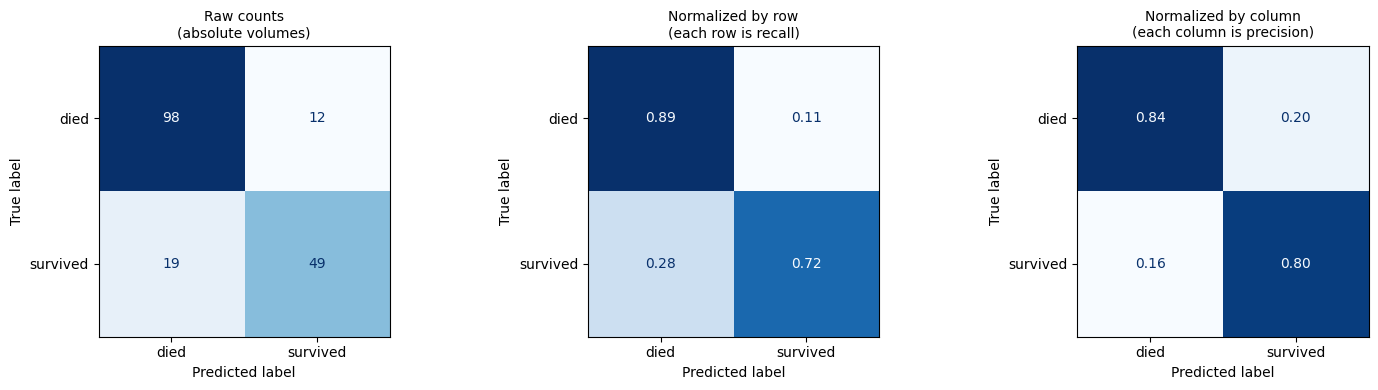

Always label the axes with real class names. 'malicious / benign'
communicates far more than '1 / 0' when presenting to stakeholders.


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, norm, title in [
        (axes[0], None, "Raw counts\n(absolute volumes)"),
        (axes[1], "true", "Normalized by row\n(each row is recall)"),
        (axes[2], "pred", "Normalized by column\n(each column is precision)")]:
    ConfusionMatrixDisplay.from_estimator(
        logreg, X_test, y_test, display_labels=labels, normalize=norm,
        cmap="Blues", ax=ax, colorbar=False, values_format=".2f"
        if norm else "d")
    ax.set_title(title, fontsize=10)
plt.tight_layout(); plt.show()

print("Always label the axes with real class names. 'malicious / benign'")
print("communicates far more than '1 / 0' when presenting to stakeholders.")


Raw counts can mislead badly when class sizes differ, which is why the normalized views matter: row-normalized reads directly as recall per class, column-normalized as precision per class, and `normalize='all'` shows each cell as a fraction of the whole dataset.

Two patterns to recognize instantly: **high FP** means the model is too aggressive and your team is drowning in false alarms, so improve precision. **High FN** means it is too conservative and threats are slipping through, so improve recall.

### Everything derives from those four cells


In [36]:
metrics_from_cells = pd.DataFrame([
    {"metric": "Accuracy", "formula": "(TP + TN) / all",
     "value": round((tp + tn) / cm.sum(), 4)},
    {"metric": "Precision", "formula": "TP / (TP + FP)",
     "value": round(tp / (tp + fp), 4)},
    {"metric": "Recall (sensitivity)", "formula": "TP / (TP + FN)",
     "value": round(tp / (tp + fn), 4)},
    {"metric": "Specificity", "formula": "TN / (TN + FP)",
     "value": round(tn / (tn + fp), 4)},
    {"metric": "False positive rate", "formula": "FP / (FP + TN)",
     "value": round(fp / (fp + tn), 4)},
    {"metric": "False discovery rate", "formula": "FP / (FP + TP)",
     "value": round(fp / (fp + tp), 4)},
]).set_index("metric")
metrics_from_cells


,formula,value
metric,,
Accuracy,(TP + TN) / all,0.8258
Precision,TP / (TP + FP),0.8033
Recall (sensitivity),TP / (TP + FN),0.7206
Specificity,TN / (TN + FP),0.8909
False positive rate,FP / (FP + TN),0.1091
False discovery rate,FP / (FP + TP),0.1967


Specificity is simply recall of the negative class, which matters in medical testing where ruling out disease is the goal. False positive rate is the x-axis of the ROC curve. False discovery rate is the complement of precision, and it is the most stakeholder-friendly of the set: "the fraction of our alerts that are false alarms."

### Precision, recall, and F1

- **Precision** is the model's credibility: when it raises an alarm, should you trust it?
- **Recall** is the model's thoroughness: is it finding everything?

They trade off against each other. Lower the threshold and you catch more true positives, raising recall, while creating more false positives and lowering precision.

**F1** is their harmonic mean, and the choice of harmonic rather than arithmetic is the entire point: precision 0.99 with recall 0.01 averages to a respectable-sounding 0.50 arithmetically, but F1 gives 0.02, correctly flagging the model as useless.


In [37]:
from sklearn.metrics import (classification_report, fbeta_score,
                             precision_recall_fscore_support)

print("Arithmetic mean of 0.99 and 0.01:", round((0.99 + 0.01) / 2, 3))
print("Harmonic mean (F1) of the same:  ",
      round(2 * (0.99 * 0.01) / (0.99 + 0.01), 3),
      "<- correctly calls it a failure")
print()
print(classification_report(y_test, y_pred, target_names=labels, digits=3))


Arithmetic mean of 0.99 and 0.01: 0.5
Harmonic mean (F1) of the same:   0.02 <- correctly calls it a failure

              precision    recall  f1-score   support

        died      0.838     0.891     0.863       110
    survived      0.803     0.721     0.760        68

    accuracy                          0.826       178
   macro avg      0.820     0.806     0.812       178
weighted avg      0.824     0.826     0.824       178



`classification_report` gives precision, recall, F1, and support for every class in one line, and it should be your default for every model you build. The averaging rows matter too: **macro** treats every class equally regardless of size, **weighted** accounts for class frequency, and **micro** is identical to accuracy for multi-class problems and therefore does not solve the imbalance problem at all.

### F-beta, when precision and recall are not equally important

F1 assumes they matter equally, which is rarely true. **F2** weights recall twice as heavily, for cases where missing positives is costly: security detection, medical screening. **F0.5** weights precision twice as heavily, for cases where false alarms are costly: spam filtering, automated account blocking.

Beta is a direct bridge from business priorities to mathematical optimization, and the value should be settled in conversation with stakeholders before the model is built.


In [38]:
for beta, use_case in [(0.5, "precision matters more (spam, auto-blocking)"),
                       (1.0, "balanced (the default)"),
                       (2.0, "recall matters more (security, screening)")]:
    print("F" + str(beta), round(fbeta_score(y_test, y_pred, beta=beta), 4),
          " ", use_case)


F0.5 0.7853   precision matters more (spam, auto-blocking)
F1.0 0.7597   balanced (the default)
F2.0 0.7357   recall matters more (security, screening)


### Threshold tuning

Most classifiers output probabilities, and the threshold converts them to labels. The 0.5 default is a mathematical convention, not an optimal operating point.


In [39]:
rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred_t = (y_proba >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred_t, average="binary", zero_division=0)
    rows.append({"threshold": t, "precision": round(p, 3),
                 "recall": round(r, 3), "F1": round(f, 3),
                 "flagged": int(pred_t.sum())})
pd.DataFrame(rows).set_index("threshold")


,precision,recall,F1,flagged
threshold,,,,
0.2,0.584,0.868,0.698,101
0.3,0.636,0.824,0.718,88
0.4,0.707,0.779,0.741,75
0.5,0.803,0.721,0.760,61
0.6,0.887,0.691,0.777,53
0.7,0.897,0.515,0.654,39
0.8,0.880,0.324,0.473,25


Read down the table and the tradeoff is unmistakable: as the threshold falls, recall climbs, precision slides, and the number of flagged cases grows. Malware detection might sit at 0.2, automated account blocking at 0.8. The right choice depends entirely on the cost of each error in your context.


---
# Section 8: ROC and PR curves

Every metric so far evaluates at a single threshold. ROC and PR curves show performance across **every** threshold at once, which is what makes them the right tool for comparing models and selecting an operating point.

- **ROC** plots true positive rate (recall) against false positive rate. Each point is a different threshold. **AUC** is the area underneath: 0.5 is random guessing, 1.0 is perfect.
- **PR** plots precision against recall, and its summary number is **average precision (AP)**.

Always plot the baseline. For ROC that is the diagonal; for PR it is a horizontal line at the positive class prevalence.


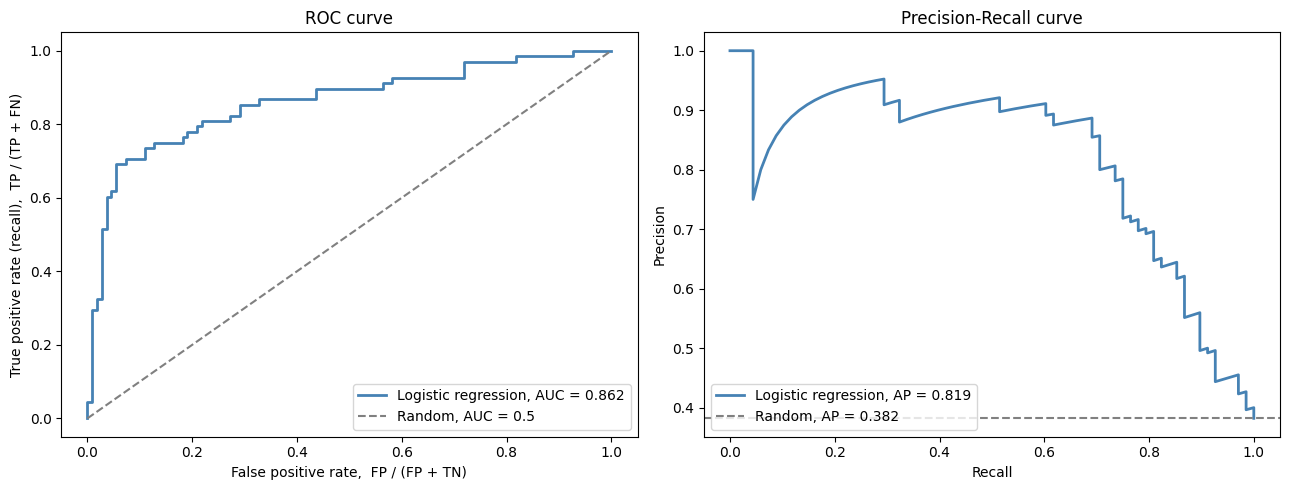

In [40]:
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)

fpr, tpr, roc_thresh = roc_curve(y_test, y_proba)
prec, rec, pr_thresh = precision_recall_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color="steelblue", linewidth=2,
             label="Logistic regression, AUC = " + str(round(auc, 3)))
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random, AUC = 0.5")
axes[0].set_xlabel("False positive rate,  FP / (FP + TN)")
axes[0].set_ylabel("True positive rate (recall),  TP / (TP + FN)")
axes[0].set_title("ROC curve"); axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, color="steelblue", linewidth=2,
             label="Logistic regression, AP = " + str(round(ap, 3)))
axes[1].axhline(y_test.mean(), linestyle="--", color="gray",
                label="Random, AP = " + str(round(y_test.mean(), 3)))
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend(loc="lower left")
plt.tight_layout(); plt.show()


### Why both, and why PR wins on imbalanced data

ROC has a critical weakness. Its x-axis is false positive rate, which divides by the number of negatives. With 99,000 negatives, even 1,000 false positives gives an FPR of just 1%, so the curve still looks excellent while your analysts drown in a thousand false alarms. PR curves have no such escape hatch, because precision divides by the number of things you flagged.

Watch the two metrics diverge on the same model as the class balance shifts.


In [41]:
proba_imb = real.predict_proba(Xi_test)[:, 1]
auc_imb = roc_auc_score(yi_test, proba_imb)
ap_imb = average_precision_score(yi_test, proba_imb)

comparison = pd.DataFrame({
    "positive rate": [str(round(y_test.mean() * 100, 1)) + "%",
                      str(round(yi_test.mean() * 100, 1)) + "%"],
    "AUC-ROC": [round(auc, 3), round(auc_imb, 3)],
    "Average precision": [round(ap, 3), round(ap_imb, 3)]},
    index=["balanced Titanic", "1% positive version"])
print(comparison)
print()
print("AUC barely moves. AP collapses. Same algorithm, same features.")
print("A model can post AUC 0.95 and AP 0.30: ROC looks great while PR")
print("reveals it cannot find positives without drowning you in false alarms.")


                    positive rate  AUC-ROC  Average precision
balanced Titanic            38.2%    0.862              0.819
1% positive version          1.8%    0.943              0.481

AUC barely moves. AP collapses. Same algorithm, same features.
A model can post AUC 0.95 and AP 0.30: ROC looks great while PR
reveals it cannot find positives without drowning you in false alarms.


Use ROC when classes are roughly balanced. Use PR when the positive class is rare, which covers fraud, malware, and intrusion detection. Report both, because they tell complementary stories and neither alone is sufficient.

Note also that **AUC-ROC is not portable across datasets** with different class distributions, so comparing a 0.92 on one dataset against a 0.89 on another says very little.

### Comparing models with curves


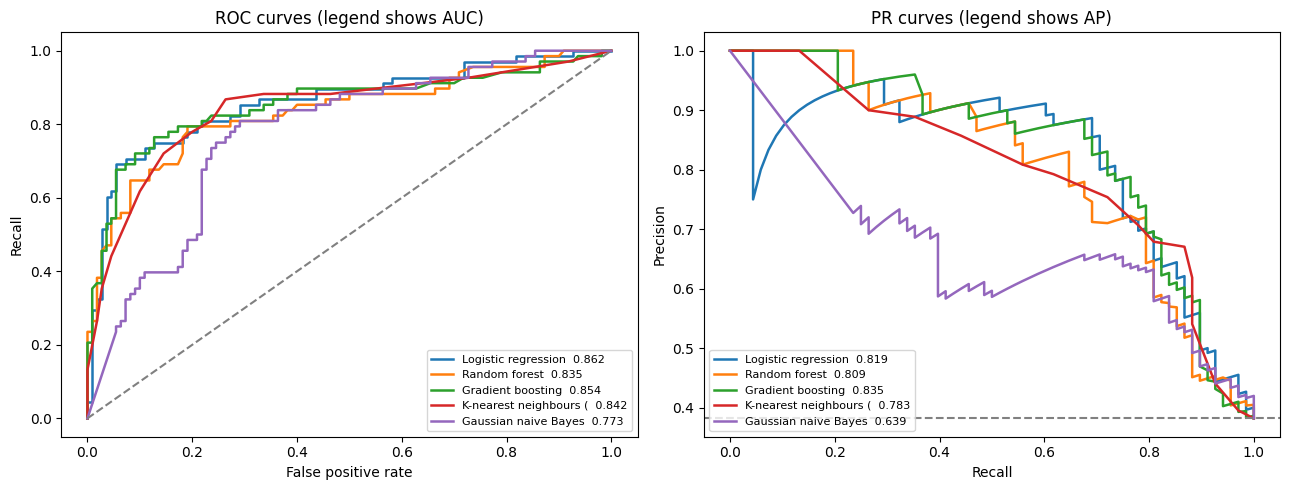

In [42]:
to_compare = ["Logistic regression", "Random forest", "Gradient boosting",
              "K-nearest neighbours (k=15)", "Gaussian naive Bayes"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in to_compare:
    m = fitted[name]
    pr_ = m.predict_proba(X_test)[:, 1]
    f, t, _ = roc_curve(y_test, pr_)
    p, r, _ = precision_recall_curve(y_test, pr_)
    axes[0].plot(f, t, linewidth=1.8,
                 label=name[:22] + "  " + str(round(roc_auc_score(y_test, pr_), 3)))
    axes[1].plot(r, p, linewidth=1.8,
                 label=name[:22] + "  " +
                 str(round(average_precision_score(y_test, pr_), 3)))

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC curves (legend shows AUC)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("Recall")
axes[0].legend(fontsize=8, loc="lower right")

axes[1].axhline(y_test.mean(), linestyle="--", color="gray")
axes[1].set_title("PR curves (legend shows AP)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()


Look for where the curves **cross**. If one curve dominates everywhere the choice is easy, but crossing is common, and it means one model is better at high recall while another is better at high precision. When that happens the right model depends on your operating point, not on the summary number. For rigorous comparison, bootstrap the test set to get confidence bands; if they overlap, the models may not be meaningfully different.

### Selecting a threshold from the curves

Three principled approaches, in increasing order of practical usefulness.


In [43]:
# 1. Youden's J statistic: the ROC point closest to the top-left corner
j_idx = int(np.argmax(tpr - fpr))
youden = roc_thresh[j_idx]

# 2. Maximize F1 on the PR curve
f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
f1_idx = int(np.argmax(f1s[:-1]))
best_f1_t = pr_thresh[f1_idx]

# 3. Constraint-based: "we need at least 90% recall, maximize precision"
TARGET_RECALL = 0.90
ok = rec[:-1] >= TARGET_RECALL
constrained = pr_thresh[ok][np.argmax(prec[:-1][ok])] if ok.any() else None

for label, t in [("Default", 0.5), ("Youden's J", youden),
                 ("Max F1", best_f1_t),
                 ("At least 90% recall", constrained)]:
    pred_t = (y_proba >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred_t, average="binary", zero_division=0)
    print(label.ljust(21), "threshold", str(round(t, 3)).rjust(6),
          "| precision", round(p, 3), "| recall", round(r, 3),
          "| F1", round(f, 3))


Default               threshold    0.5 | precision 0.803 | recall 0.721 | F1 0.76
Youden's J            threshold  0.601 | precision 0.887 | recall 0.691 | F1 0.777
Max F1                threshold  0.601 | precision 0.887 | recall 0.691 | F1 0.777
At least 90% recall   threshold  0.142 | precision 0.5 | recall 0.912 | F1 0.646


The constraint-based approach is the one that survives contact with stakeholders, because it starts from a requirement they actually have: "we need to catch 90% of fraud, what is the best precision we can get?" That is a direct conversation between technical metrics and business needs.

**Never select a threshold on the test set.** We just did, for teaching purposes, and in real work that decision belongs on a validation set so the test set stays untouched.

### Calibration

AUC measures **ranking**, not probability quality. A model can rank perfectly while its probabilities are systematically wrong, which matters whenever a downstream decision uses the number itself rather than the ordering, such as expected-loss calculations.


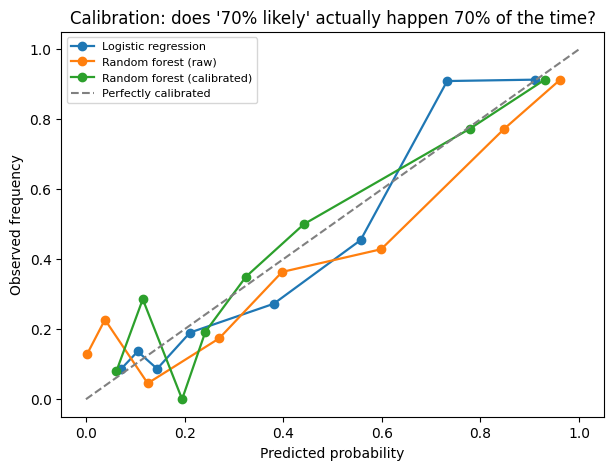

In [44]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

rf_raw = fitted["Random forest"]
rf_cal = CalibratedClassifierCV(
    make_pipeline(RandomForestClassifier(n_estimators=300,
                                         random_state=RANDOM_STATE)),
    method="isotonic", cv=5).fit(X_train, y_train)

plt.figure(figsize=(7, 5))
for label, model in [("Logistic regression", logreg),
                     ("Random forest (raw)", rf_raw),
                     ("Random forest (calibrated)", rf_cal)]:
    pr_ = model.predict_proba(X_test)[:, 1]
    true_p, pred_p = calibration_curve(y_test, pr_, n_bins=8, strategy="quantile")
    plt.plot(pred_p, true_p, "o-", linewidth=1.6, label=label)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.title("Calibration: does '70% likely' actually happen 70% of the time?")
plt.legend(fontsize=8); plt.show()


Logistic regression tends to sit close to the diagonal because log loss rewards honest probabilities directly. Tree ensembles are often overconfident at the extremes, and `CalibratedClassifierCV` corrects that without changing the ranking.

---
# Section 9: Interpret the results

The metrics are computed. Now the question that actually matters: **what should we optimize for?** That answer is not mathematical, it is a business decision.

### Cost-sensitive evaluation

Not all errors are equal.

- **Recall matters more** when missing the event is catastrophic: medical screening, security detection, safety systems.
- **Precision matters more** when false alarms carry severe consequences: spam filtering, criminal justice, automated blocking.

The practice worth adopting: ask stakeholders explicitly, "what is worse, a missed detection or a false alarm?" before choosing a metric or a threshold. In security the answer usually leans toward recall, because missing an attack can mean a breach while a false alarm costs analyst time.

Let's put actual numbers on it and let the cost model choose the threshold.


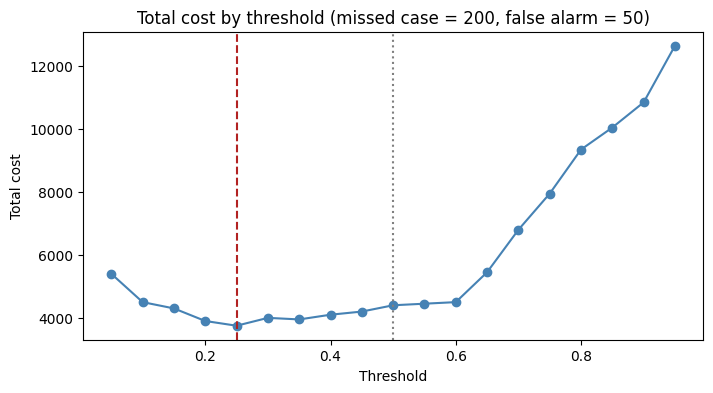

Cost-optimal threshold: 0.25 with total cost 3750
Cost at the default 0.5: 4400


In [45]:
COST_FN = 200     # cost of missing a positive case
COST_FP = 50      # cost of investigating a false alarm

rows = []
for t in np.arange(0.05, 0.96, 0.05):
    pred_t = (y_proba >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, pred_t).ravel()
    rows.append({"threshold": round(t, 2), "FP": fp_, "FN": fn_,
                 "total cost": fp_ * COST_FP + fn_ * COST_FN})
costs = pd.DataFrame(rows)
best = costs.loc[costs["total cost"].idxmin()]

plt.figure(figsize=(8, 4))
plt.plot(costs["threshold"], costs["total cost"], "o-", color="steelblue")
plt.axvline(best["threshold"], color="firebrick", linestyle="--")
plt.axvline(0.5, color="gray", linestyle=":")
plt.title("Total cost by threshold (missed case = 200, false alarm = 50)")
plt.xlabel("Threshold"); plt.ylabel("Total cost")
plt.show()

print("Cost-optimal threshold:", best["threshold"],
      "with total cost", int(best["total cost"]))
print("Cost at the default 0.5:",
      int(costs.loc[costs['threshold'] == 0.5, 'total cost'].iloc[0]))


When a missed case costs four times a false alarm, the cost-optimal threshold drops well below the default 0.5, and the saving over running at 0.5 is substantial. Nothing about the model changed; only the business context did. Change the ratio in that cell and watch the optimum move, because that single number encodes a decision your stakeholders own, not you.

### Alert fatigue

There is a ceiling on recall that no metric will tell you about. Analyst effectiveness drops sharply once daily alert volume exceeds team capacity, typically somewhere around 50 to 100 alerts. A high-recall, low-precision model buries real threats in noise and analysts start skipping alerts. **That is a false negative outcome caused by too many false positives**, and it will not appear anywhere in your F1 score.


In [46]:
SOC_CAPACITY = 25          # alerts this team can actually investigate per day

rows = []
for t in np.arange(0.1, 0.91, 0.1):
    pred_t = (y_proba >= t).astype(int)
    flagged = int(pred_t.sum())
    p, r, _, _ = precision_recall_fscore_support(
        y_test, pred_t, average="binary", zero_division=0)
    rows.append({"threshold": round(t, 2), "alerts": flagged,
                 "precision": round(p, 3), "recall": round(r, 3),
                 "within capacity": "yes" if flagged <= SOC_CAPACITY else "NO"})
pd.DataFrame(rows).set_index("threshold")


,alerts,precision,recall,within capacity
threshold,,,,
0.1,148,0.446,0.971,NO
0.2,101,0.584,0.868,NO
0.3,88,0.636,0.824,NO
0.4,75,0.707,0.779,NO
0.5,61,0.803,0.721,NO
0.6,53,0.887,0.691,NO
0.7,39,0.897,0.515,NO
0.8,25,0.880,0.324,yes
0.9,15,0.933,0.206,yes


If the team can handle 25 alerts and the model generates 90, raise the threshold regardless of what the metrics say on paper. Mitigations that work: tune the threshold to match capacity, tier alerts by confidence so low-confidence ones auto-resolve and high-confidence ones escalate immediately, and track analyst response time as a downstream measure of model quality. A model that generates ten times the alerts but takes five times longer to investigate is not an improvement even if its F1 is higher.

### Translate every metric into business language

"Recall 0.95" means nothing to a CISO. "We catch 95% of fraudulent transactions" is actionable.


In [47]:
p, r, f1v, _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary", zero_division=0)

print("MODEL SUMMARY, in plain language")
print("=" * 62)
print("Of the passengers we predict survived,",
      str(round(p * 100)) + "% actually did.        (precision)")
print("We correctly identify",
      str(round(r * 100)) + "% of everyone who actually survived. (recall)")
print("Overall we are right", str(round(accuracy_score(y_test, y_pred) * 100))
      + "% of the time.                 (accuracy)")
print(str(round((1 - p) * 100)) + "% of our positive predictions are false alarms."
      "        (false discovery rate)")
print("Ranking quality across all thresholds:",
      round(auc, 3), "of a possible 1.0.   (AUC)")
print("=" * 62)
print("Baseline to beat:", round(y_test.value_counts(normalize=True).max(), 3),
      "accuracy by always guessing the majority class.")


MODEL SUMMARY, in plain language
Of the passengers we predict survived, 80% actually did.        (precision)
We correctly identify 72% of everyone who actually survived. (recall)
Overall we are right 83% of the time.                 (accuracy)
20% of our positive predictions are false alarms.        (false discovery rate)
Ranking quality across all thresholds: 0.862 of a possible 1.0.   (AUC)
Baseline to beat: 0.618 accuracy by always guessing the majority class.


### The evaluation dashboard

Every deployed model deserves a single-page dashboard, regenerated automatically on each retrain: the confusion matrix in both raw and normalized form, a summary table of precision, recall, F1, and accuracy, ROC and PR curves with AUC and AP, the threshold in use and the rationale for it, business-language translations next to every technical number, and trend lines over the last 30, 60, and 90 days. Tools like MLflow or Weights and Biases automate this, as does a scheduled matplotlib script.

### Monitoring in production

Training metrics are not deployment metrics. Real-world performance drifts because distributions shift, data quality degrades, and adversaries adapt.

- **Monitor the prediction distribution.** This works even without ground truth: if scores that used to separate cleanly now cluster around 0.5, confidence has degraded.
- **Compute live metrics** whenever ground truth eventually arrives.
- **Set automated triggers**, such as "if weekly recall drops below 0.85, start the retraining pipeline."
- **Track feature distributions**, since input drift usually precedes metric degradation.
- **Log every prediction** with timestamp, features, score, and eventual outcome. In security that audit trail is essential for incident investigation.

### Putting it all together

Start with the business problem and ask what decision the model supports. Identify the cost of each error type with stakeholders **before** building, because post-hoc metric selection is a form of p-hacking. Choose your primary metric from those costs. Establish baselines and beat them. Evaluate with the full toolkit rather than one number. Deploy with monitoring. Then iterate, using the evaluation results to guide feature engineering, threshold tuning, and retraining schedules.

Evaluation is not an afterthought. It is the bridge between technical work and real-world outcomes.


---
# Wrap-up

What actually happened in this notebook:

- A **stratified split** kept both halves representative, and at a 1% positive rate we saw random splitting produce test sets with zero positives.
- **Logistic regression** turned a linear combination into a probability through the sigmoid, learned coefficients we could read and convert into odds, and set a baseline everything else had to beat.
- **Decision boundaries** made model complexity visible: one clean line, a few rectangles, a checkerboard of memorized noise.
- **Thirteen algorithms** produced a leaderboard whose top entries were separated by less than the noise of a single split, while their interpretability and training costs differed by orders of magnitude.
- **Cross-validation** replaced that lucky single number with a mean and a spread, and grouped and time-series variants showed how much the right splitting strategy matters.
- **Metrics** exposed the accuracy paradox, and the four cells of the confusion matrix generated every other number we needed.
- **ROC and PR curves** showed the same model looking excellent by AUC and mediocre by AP once the positive class got rare.
- **Cost and capacity** moved the threshold further than any algorithm choice did.

If you take one habit away, make it this: **always report training and test numbers together, alongside a baseline.** The gap between those two numbers is the most honest thing your model will ever tell you.

**Next up, Module 5:** ML security and adversarial attacks, where we return to the fact that every model we just built is also an attack surface.


---
# Try it yourself (optional)

**Exercise 1.** Using `RepeatedStratifiedKFold` with 5 folds and 4 repeats, compare `RandomForestClassifier` against `LogisticRegression` on average precision. Is the difference larger than the combined spread of the two?

**Exercise 2.** Pick the threshold that maximizes the F2 score (recall weighted twice as heavily as precision) and report the precision and recall at that operating point. How does it compare to the F1-optimal threshold?

**Exercise 3.** Train a `DecisionTreeClassifier` with `max_depth` from 1 to 15 and plot the cross-validated AUC against the train-test gap on the same figure. Identify the depth where the gap starts growing faster than the score.


In [48]:
# Exercise workspace





---
## Exercise solutions


In [49]:
# Exercise 1: is the random forest really better?
rskf4 = RepeatedStratifiedKFold(n_splits=5, n_repeats=4,
                                random_state=RANDOM_STATE)
res = {}
for name, model in [("Logistic regression",
                     LogisticRegression(max_iter=1000,
                                        random_state=RANDOM_STATE)),
                    ("Random forest",
                     RandomForestClassifier(n_estimators=300,
                                            random_state=RANDOM_STATE))]:
    s = cross_val_score(make_pipeline(model), X, y, cv=rskf4,
                        scoring="average_precision")
    res[name] = s
    print(name.ljust(22), round(s.mean(), 4), "+/-", round(s.std(), 4))

diff = abs(res["Random forest"].mean() - res["Logistic regression"].mean())
spread = res["Random forest"].std() + res["Logistic regression"].std()
print()
print("Difference in means:", round(diff, 4), "| combined spread:",
      round(spread, 4))
print("Verdict:", "a real difference" if diff > spread
      else "inside the noise, treat the models as equivalent")


Logistic regression    0.8243 +/- 0.0311
Random forest          0.8211 +/- 0.0449

Difference in means: 0.0032 | combined spread: 0.076
Verdict: inside the noise, treat the models as equivalent


In [50]:
# Exercise 2: the F2-optimal threshold
f2_scores = [(t, fbeta_score(y_test, (y_proba >= t).astype(int), beta=2,
                             zero_division=0))
             for t in np.arange(0.05, 0.96, 0.01)]
best_t, best_f2 = max(f2_scores, key=lambda pair: pair[1])

for label, t in [("F1-optimal", best_f1_t), ("F2-optimal", best_t)]:
    pred_t = (y_proba >= t).astype(int)
    p, r, _, _ = precision_recall_fscore_support(
        y_test, pred_t, average="binary", zero_division=0)
    print(label.ljust(12), "threshold", round(t, 3),
          "| precision", round(p, 3), "| recall", round(r, 3))
print()
print("F2 pushes the threshold down, buying recall at the cost of precision,")
print("which is the correct trade when a missed case is the expensive error.")


F1-optimal   threshold 0.601 | precision 0.887 | recall 0.691
F2-optimal   threshold 0.23 | precision 0.621 | recall 0.868

F2 pushes the threshold down, buying recall at the cost of precision,
which is the correct trade when a missed case is the expensive error.


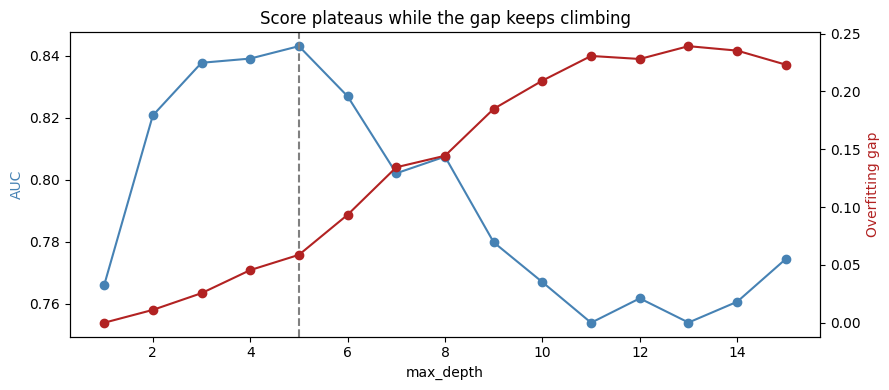

Best depth by AUC: 5
Past that point the model buys memorization, not performance.


In [51]:
# Exercise 3: where does the gap start outrunning the score?
depths = range(1, 16)
aucs, gaps = [], []
for d in depths:
    p = make_pipeline(DecisionTreeClassifier(max_depth=d,
                                             random_state=RANDOM_STATE))
    cv = cross_validate(p, X, y, cv=5, scoring="roc_auc",
                        return_train_score=True)
    aucs.append(cv["test_score"].mean())
    gaps.append(cv["train_score"].mean() - cv["test_score"].mean())

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(depths, aucs, "o-", color="steelblue", label="cross-validated AUC")
ax1.set_xlabel("max_depth"); ax1.set_ylabel("AUC", color="steelblue")
ax2 = ax1.twinx()
ax2.plot(depths, gaps, "o-", color="firebrick", label="train minus test gap")
ax2.set_ylabel("Overfitting gap", color="firebrick")
ax1.axvline(depths[int(np.argmax(aucs))], color="gray", linestyle="--")
plt.title("Score plateaus while the gap keeps climbing")
plt.tight_layout(); plt.show()

print("Best depth by AUC:", depths[int(np.argmax(aucs))])
print("Past that point the model buys memorization, not performance.")
